### 1. Setup

In [ ]:
# use R Magic
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### 2. Create a custom R library directory and set R_LIBS_USER
Create a directory in Google Drive where R packages will be installed and set the `R_LIBS_USER` environment variable to point to this directory. This tells R where to look for your personal packages. You only need to run this cell once to set up the directory and install packages. In subsequent sessions, you only need to run the `drive.mount` and `Sys.setenv` commands.

In [ ]:
%%R
# Define the path to your desired output folder in Google Drive
output_dir = '/content/drive/MyDrive/Data Science 551 MLB Draft WAR Final Project'

# Create the directory if it doesn't exist
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

message(paste('Output directory set to:', output_dir))

Output directory set to: /content/drive/MyDrive/Data Science 551 MLB Draft WAR Final Project


### 3. Pull rstan from drive, but install packages that had install errors (baseballr) in drive one time in session

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Choose a folder on Drive for R libraries
r_drive_lib = "/content/drive/MyDrive/R_Libs"
os.makedirs(r_drive_lib, exist_ok=True)

# Tell R to use this as R_LIBS_USER
os.environ["R_LIBS_USER"] = r_drive_lib
r_drive_lib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/R_Libs'

In [ ]:
%%R
# Setup two libraries
drive_lib   <- Sys.getenv("R_LIBS_USER")
session_lib <- "/usr/local/lib/R/site-library"   # Colab’s main library

.libPaths(c(drive_lib, session_lib, .libPaths()))
.libPaths()


[1] "/content/drive/MyDrive/R_Libs" "/usr/local/lib/R/site-library"
[3] "/usr/lib/R/site-library"       "/usr/lib/R/library"           


In [ ]:
# Only needed to run this once (install large slow packages to drive)
%%R
drive_lib <- Sys.getenv("R_LIBS_USER")

install.packages(
  "StanHeaders",
  lib   = drive_lib,
  repos = c("https://mc-stan.org/r-packages/", getOption("repos"))
)

install.packages(
  "rstan",
  lib   = drive_lib,
  repos = c("https://mc-stan.org/r-packages/", getOption("repos"))
)

install.packages("bayesplot", lib = drive_lib) # isnt working for some reason
install.packages("shinystan", lib = drive_lib)
install.packages("dplyr",   lib = drive_lib, repos = getOption("repos"))
install.packages("writexl", lib = drive_lib, repos = getOption("repos"))

message("Big packages installed to Drive library.")


also installing the dependency ‘RcppEigen’

trying URL 'https://cran.rstudio.com/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/StanHeaders_2.32.10.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpsJ9fC4/downloaded_packages’
also installing the dependencies ‘numDeriv’, ‘abind’, ‘tensorA’, ‘distributional’, ‘checkmate’, ‘matrixStats’, ‘posterior’, ‘inline’, ‘gridExtra’, ‘loo’, ‘QuickJSR’, ‘BH’

trying URL 'https://cran.rstudio.com/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/abind_1.4-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tensorA_0.36.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/distributional_0.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/checkmate_2.3.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/matrixStats_1.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/posterior_1.6.1.tar.gz'
trying URL 'https://cran.rstudio.

In [ ]:
%%R
# Install package one time for session
session_lib <- "/usr/local/lib/R/site-library"

install.packages("baseballr",
                 lib   = session_lib,
                 repos = getOption("repos"))

# install.packages("shinystan",lib   = session_lib) too slow, install in drive lib

message("baseballr installed to session-only library.")


trying URL 'https://cran.rstudio.com/src/contrib/baseballr_1.6.0.tar.gz'
Content type 'application/x-gzip' length 306551 bytes (299 KB)
downloaded 299 KB


The downloaded source packages are in
	‘/tmp/RtmpKzyyXQ/downloaded_packages’
baseballr installed to session-only library.


In [ ]:
%%R
library(StanHeaders)
library(baseballr)
library(dplyr)
library(writexl)
library(lubridate)
library(purrr)
library(stringr)
library(rstan)
library(matrixStats)
# library(shinystan)


In [ ]:
%%R
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())

In [ ]:
%%R
knitr::opts_chunk$set(echo = TRUE, comment = "#>", collapse = TRUE,
                      fig.width = 6, fig.asp = 0.618,
                      out.width = "70%", fig.align = "center")
comma <- function(x, digits. = 2L) {
    format(x, digits = digits., big.mark = ",")
}

# 4. Building Dataset. Skip to Section 5. Building Bayesian Model to just pull final dataset from excel.

In [ ]:
%%R
# Get information about drafted players

df15 <- mlb_draft(year = 2015)
df16 <- mlb_draft(year = 2016)
df17 <- mlb_draft(year = 2017)
df18 <- mlb_draft(year = 2018)

draft <- dplyr::bind_rows(df15, df16, df17, df18)

In [ ]:
%%R
# Look at players drafted multiple times
multi_drafted <- draft %>%
  dplyr::count(person_id, sort = TRUE) %>%
  dplyr::filter(n > 1)

multi_drafted %>% head()


── MLB Draft data from MLB.com ────────────────────────────── baseballr 1.6.0 ──
ℹ Data updated: 2025-12-15 17:17:02 UTC
# A tibble: 6 × 2
  person_id     n
      <int> <int>
1    621117     3
2    663714     3
3    663929     3
4    663937     3
5    663941     3
6    663972     3


In [ ]:
%%R
# Pull in our dependent variable Wins Above Replacement (WAR). Pull Hitter and Pitcher WAR separately and combine
# Hitter WAR

years <- 2015:2025   # change this to whatever range you want

bat_war_multi <- map_dfr(years, function(yr) {
  message("Fetching WAR for season ", yr, "...")

  fg_batter_leaders(
    startseason = as.character(yr),
    endseason   = as.character(yr),
    qual        = "0",        # include everyone
    ind          = "0",        # aggregate by season
    stats       = "bat",
    pos         = "all",
    lg          = "all",
    sortstat    = "WAR",
    sortdir     = "desc",
    pageitems   = "10000"
  ) %>%
    mutate(season = yr)       # explicitly tag the season
})

glimpse(bat_war_multi)

Rows: 15,521
Columns: 351
$ Season              <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 20…
$ team_name           <chr> "WSN", "LAA", "TOR", "CIN", "ARI", "SFG", "ARI", "…
$ Bats                <chr> "L", "R", "R", "L", "R", "R", "R", "R", "R", "R", …
$ xMLBAMID            <int> 547180, 545361, 518626, 458015, 502671, 457763, 57…
$ PlayerNameRoute     <chr> "Bryce Harper", "Mike Trout", "Josh Donaldson", "J…
$ PlayerName          <chr> "Bryce Harper", "Mike Trout", "Josh Donaldson", "J…
$ playerid            <int> 11579, 10155, 5038, 4314, 9218, 9166, 9256, 11493,…
$ Age                 <int> 22, 23, 29, 31, 27, 28, 27, 22, 29, 23, 28, 29, 29…
$ AgeRng              <chr> "22 - 22", "23 - 23", "29 - 29", "31 - 31", "27 - …
$ SeasonMin           <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 20…
$ SeasonMax           <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 20…
$ G                   <int> 153, 159, 158, 158, 159, 150, 157, 162, 140, 151, …
$ AB          

Fetching WAR for season 2015...
Fetching WAR for season 2016...
Fetching WAR for season 2017...
Fetching WAR for season 2018...
Fetching WAR for season 2019...
Fetching WAR for season 2020...
Fetching WAR for season 2021...
Fetching WAR for season 2022...
Fetching WAR for season 2023...
Fetching WAR for season 2024...
Fetching WAR for season 2025...


In [ ]:
%%R
# Pitcher WAR

# Choose  seasons
years <- 2015:2025

# 1) Pull pitcher WAR leaderboards for each year and stack them
pit_war_multi <- map_dfr(years, function(yr) {
  message("Fetching PITCHER WAR for season ", yr, "...")

  fg_pitcher_leaders(
    startseason = as.character(yr),
    endseason   = as.character(yr),
    qual        = "0",        # include everyone, not just qualified
    ind         = "0",        # 0 = aggregate for that season
    stats       = "pit",
    pos         = "all",
    lg          = "all",
    sortstat    = "WAR",
    sortdir     = "desc",
    pageitems   = "10000"
  ) %>%
    mutate(season = yr)
})

glimpse(pit_war_multi)

Rows: 8,968
Columns: 424
$ Season              <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 20…
$ team_name           <chr> "LAD", "CHC", "- - -", "WSN", "HOU", "CHW", "CLE",…
$ Throws              <chr> "L", "R", "L", "R", "L", "L", "R", "R", "R", "R", …
$ xMLBAMID            <int> 477132, 453562, 456034, 453286, 572971, 519242, 44…
$ PlayerNameRoute     <chr> "Clayton Kershaw", "Jake Arrieta", "David Price", …
$ PlayerName          <chr> "Clayton Kershaw", "Jake Arrieta", "David Price", …
$ playerid            <int> 2036, 4153, 3184, 3137, 9434, 10603, 2429, 1943, 6…
$ Age                 <int> 27, 29, 29, 30, 27, 26, 29, 31, 26, 24, 25, 31, 27…
$ AgeRng              <chr> "27 - 27", "29 - 29", "29 - 29", "30 - 30", "27 - …
$ SeasonMin           <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 20…
$ SeasonMax           <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 20…
$ W                   <int> 16, 22, 18, 14, 20, 13, 9, 19, 12, 19, 18, 11, 14,…
$ L            

Fetching PITCHER WAR for season 2015...
Fetching PITCHER WAR for season 2016...
Fetching PITCHER WAR for season 2017...
Fetching PITCHER WAR for season 2018...
Fetching PITCHER WAR for season 2019...
Fetching PITCHER WAR for season 2020...
Fetching PITCHER WAR for season 2021...
Fetching PITCHER WAR for season 2022...
Fetching PITCHER WAR for season 2023...
Fetching PITCHER WAR for season 2024...
Fetching PITCHER WAR for season 2025...


In [ ]:
%%R
# Combine batter and pitcher and make sure to group by season
war_seasonal <- full_join(
  bat_war_multi %>%
    select(xMLBAMID, PlayerName, season,
           WAR_bat = WAR, G_bat = G),
  pit_war_multi %>%
    select(xMLBAMID, PlayerName, season,
           WAR_pit = WAR, G_pit = G),
  by = c("xMLBAMID", "PlayerName", "season")
) %>%
  mutate(
    WAR_bat = coalesce(WAR_bat, 0),
    WAR_pit = coalesce(WAR_pit, 0),
    WAR_season   = WAR_bat + WAR_pit,
    G_bat = coalesce(G_bat, 0),
    G_pit = coalesce(G_pit, 0),
    G_season     = G_bat + G_pit
  )

  glimpse(war_seasonal)

Rows: 15,521
Columns: 9
$ xMLBAMID   <int> 547180, 545361, 518626, 458015, 502671, 457763, 572041, 592…
$ PlayerName <chr> "Bryce Harper", "Mike Trout", "Josh Donaldson", "Joey Votto…
$ season     <int> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015,…
$ WAR_bat    <dbl> 9.3157, 9.2990, 8.7110, 7.2540, 7.2300, 6.7721, 6.7689, 6.5…
$ G_bat      <dbl> 153, 159, 158, 158, 159, 150, 157, 162, 140, 151, 157, 130,…
$ WAR_pit    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ G_pit      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ WAR_season <dbl> 9.3157, 9.2990, 8.7110, 7.2540, 7.2300, 6.7721, 6.7689, 6.5…
$ G_season   <dbl> 153, 159, 158, 158, 159, 150, 157, 162, 140, 151, 157, 130,…


In [ ]:
%%R
draft_last <- draft %>%
  mutate(draft_year = as.integer(year)) %>%
  group_by(person_id) %>%
  arrange(draft_year, pick_number, .by_group = TRUE) %>%
  slice_tail(n = 1) %>%   # last draft for each player
  ungroup()

In [ ]:
%%R
draft_war_season <- draft_last %>%
  mutate(draft_year = as.integer(year)) %>%
  left_join(
    war_seasonal,
    by = c("person_id" = "xMLBAMID")
  )

glimpse(draft_war_season)

Rows: 6,640
Columns: 92
$ bis_player_id                        <int> 356917, 369677, 369921, 363994, 3…
$ pick_round                           <chr> "17", "11", "4", "4", "4", "4", "…
$ pick_number                          <int> 521, 336, 136, 116, 116, 116, 116…
$ display_pick_number                  <int> 521, 336, 136, 116, 116, 116, 116…
$ round_pick_number                    <int> 26, 21, 30, 11, 11, 11, 11, 26, 1…
$ headshot_link                        <chr> "https://img.mlbstatic.com/mlb-ph…
$ is_drafted                           <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRU…
$ is_pass                              <lgl> FALSE, FALSE, FALSE, FALSE, FALSE…
$ year                                 <chr> "2015", "2015", "2016", "2015", "…
$ school_name                          <chr> "LSU", "Texas", "Southern Califor…
$ person_id                            <int> 546992, 546994, 546999, 547001, 5…
$ person_full_name                     <chr> "Chris Chinea", "C.J. Hinojosa", …
$ person_link   

In [ ]:
%%R
# Summarize WAR only if it was produced within 7 full years of being drafted.
# Also mark player as reached MLB if they played a game in the majors during the 7 year window.
draft_war_7 <- draft_war_season %>%
  mutate(
    # logical: is this season within the 7-year window?
    in_7yr_window = !is.na(season) &
                    season >= draft_year &
                    season <= draft_year + 7,

    # Calculate age as of June 1 of the draft year
    june_1_date = ymd(paste0(year, "-06-01")),
    person_birth_date_ymd = ymd(person_birth_date),
    age_june_1 = interval(person_birth_date_ymd, june_1_date) / months(1) # Changed to months
  ) %>%
  group_by(person_id, person_full_name, year, team_name, school_name, rank, person_birth_date, age_june_1, person_primary_position_type, person_bat_side_code, person_pitch_hand_code, pick_round, pick_number, person_height) %>%
  summarise(
    WAR_7yr = sum(if_else(in_7yr_window, WAR_season, 0), na.rm = TRUE),
    G_7yr   = sum(if_else(in_7yr_window, G_season,   0L), na.rm = TRUE),
    reached_mlb_7yr = G_7yr > 0,
    age_june_1 = first(age_june_1),
    .groups = "drop"
  )

In [ ]:
%%R
# Write to excel so we can use chatgpt to categorize schools.
# library(writexl)
write_xlsx(draft_war_7, file.path(output_dir, "draft_war_7yr_round_pick_height.xlsx"))

Used this chatgpt discussion to add a column for school type between high school, JUCO and College:
https://chatgpt.com/share/69403fc9-adc4-8010-93c0-771bfb2df884

Then, I uploaded that new file that chatgpt outputs to drive and to my github, from which we can pull it below.

### 5. Building Bayesian Model

In [ ]:
%%R
# Pull dataset from github
download.file(
  "https://raw.githubusercontent.com/EvanDelcamp/mlb-draft-war-project/main/draft_war_7yr_2017_2018.xlsx",
  destfile = "draft.xlsx",
  mode = "wb"
)

library(readxl)
df <- read_excel("draft.xlsx")
head(df)


# A tibble: 6 × 18
  person_id person_full_name  year team_name school_name  rank person_birth_date
      <dbl> <chr>            <dbl> <chr>     <chr>       <dbl> <chr>            
1    546992 Chris Chinea      2015 St. Loui… LSU            NA 1994-05-03       
2    546994 C.J. Hinojosa     2015 San Fran… Texas          NA 1994-07-15       
3    546999 Jeremy Martinez   2016 St. Loui… Southern C…    NA 1994-12-29       
4    547001 Cody Poteet       2015 Miami Ma… UCLA           NA 1994-07-30       
5    547177 Phil Pfeifer      2015 Los Ange… Vanderbilt     NA 1992-07-15       
6    592138 Kirby Bellow      2015 Arizona … Texas          NA 1991-11-14       
# ℹ 11 more variables: age_june_1 <dbl>, person_primary_position_type <chr>,
#   person_bat_side_code <chr>, person_pitch_hand_code <chr>, pick_round <chr>,
#   pick_number <dbl>, person_height <chr>, WAR_7yr <dbl>, G_7yr <dbl>,
#   reached_mlb_7yr <lgl>, school_type_3cat <chr>


trying URL 'https://raw.githubusercontent.com/EvanDelcamp/mlb-draft-war-project/main/draft_war_7yr_2017_2018.xlsx'
Content type 'application/octet-stream' length 422657 bytes (412 KB)
downloaded 412 KB



In [ ]:
%%R
# transformations of variables other than rank
df_clean <- df %>%
  mutate(
    # basic outcome
    WAR_7yr   = as.numeric(WAR_7yr),
    G_7yr     = as.integer(G_7yr),
    reached_mlb_7yr = as.integer(reached_mlb_7yr),
    pick_number = as.integer(pick_number),

    # age: center for stability
    age_c = age_june_1 - mean(age_june_1, na.rm = TRUE),

    draft_year_factor = factor(year),         # or whatever your draft year column is
    year_id = as.integer(draft_year_factor),   # 1,...,T

    # simplify position: treat "Hitter" as infielder for now
    pos_simple = case_when(
      person_primary_position_type == "Pitcher"   ~ "Pitcher",
      person_primary_position_type == "Catcher"   ~ "Catcher",
      person_primary_position_type == "Outfielder"~ "Outfielder",
      person_primary_position_type %in% c("Infielder", "Hitter") ~ "Infielder",
      TRUE ~ "Other"
    ),

    # pitcher vs non-pitcher (key covariate)
    is_pitcher = (pos_simple == "Pitcher"),

    # school type as factor: choose HighSchool as baseline
    school_type_3cat = factor(
      school_type_3cat,
      levels = c("High School", "College", "JUCO")
    ),

    # batting / throwing handedness — simplify to L vs non-L if you want
    bat_side = factor(person_bat_side_code,
                      levels = c("R", "L", "S")),
    throw_hand = factor(person_pitch_hand_code,
                        levels = c("R", "L")),

    # Convert height from "feet' inches"" to total inches
    height_inches = case_when(
      !is.na(person_height) ~ {
        height_parts <- str_match(person_height, "(\\d+)'\\s*(\\d*)\"")
        feet <- as.numeric(height_parts[, 2])
        inches <- as.numeric(height_parts[, 3])
        if_else(is.na(inches), feet * 12, feet * 12 + inches)
      },
      TRUE ~ NA_real_
    )
  )

In [ ]:
# Quick side frequentist analysis to check the impact of prospect rankings

In [ ]:
%%R
# Transformation for rank
library(dplyr)

df_rank <- df_clean %>%
  filter(year %in% c(2017, 2018)) %>%   # only years with rankings
  mutate(
    ranked     = !is.na(rank),         # TRUE if in the top-200 list
    # transform rank so bigger number = better prospect
    # 1 -> 200, 200 -> 1, NA stays NA for now
    rank_score = if_else(ranked, 201 - rank + 1, NA_real_)
  )


In [ ]:
%%R
# Regression checking the impact of ranks on reaching mlb. Seems to be signficant.
df_rank_all <- df_rank %>%
  mutate(
    # replace NA rank_score for unranked players with 0
    rank_score = if_else(ranked, rank_score, 0)
  )

glm_reach_rank2 <- glm(
  reached_mlb_7yr ~ ranked + rank_score + school_type_3cat + is_pitcher + age_c + bat_side + throw_hand,
  data   = df_rank_all,
  family = binomial
)

summary(glm_reach_rank2)



Call:
glm(formula = reached_mlb_7yr ~ ranked + rank_score + school_type_3cat + 
    is_pitcher + age_c + bat_side + throw_hand, family = binomial, 
    data = df_rank_all)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -3.277993   0.257792 -12.716  < 2e-16 ***
rankedTRUE               0.500971   0.251498   1.992 0.046377 *  
rank_score               0.013945   0.002065   6.754 1.44e-11 ***
school_type_3catCollege  1.358356   0.299974   4.528 5.95e-06 ***
school_type_3catJUCO     0.823009   0.310055   2.654 0.007945 ** 
is_pitcherTRUE           0.370029   0.128125   2.888 0.003877 ** 
age_c                   -0.025209   0.006846  -3.682 0.000231 ***
bat_sideL                0.174475   0.162448   1.074 0.282806    
bat_sideS                0.178461   0.325872   0.548 0.583939    
throw_handL              0.126208   0.182294   0.692 0.488729    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parame

In [ ]:
# WAR7 regression with Ranking to check impact overall. Rank score seems to matter here some
%%R
model_lm <- lm(
  WAR_7yr ~ ranked + rank_score + school_type_3cat + is_pitcher + age_c + bat_side + throw_hand,
  data = df_rank_all
)

summary(model_lm)


Call:
lm(formula = WAR_7yr ~ ranked + rank_score + school_type_3cat + 
    is_pitcher + age_c + bat_side + throw_hand, data = df_rank_all)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.9709 -0.2204 -0.1287 -0.0454 22.1327 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             -0.170488   0.116234  -1.467  0.14257    
rankedTRUE              -0.023931   0.148248  -0.161  0.87177    
rank_score               0.007586   0.001223   6.202 6.56e-10 ***
school_type_3catCollege  0.402892   0.144310   2.792  0.00528 ** 
school_type_3catJUCO     0.134112   0.144055   0.931  0.35196    
is_pitcherTRUE          -0.027149   0.060480  -0.449  0.65355    
age_c                   -0.006948   0.003168  -2.193  0.02839 *  
bat_sideL                0.040299   0.078018   0.517  0.60553    
bat_sideS                0.222611   0.158605   1.404  0.16058    
throw_handL              0.029574   0.090761   0.326  0.74457    
---
Signif. codes:  0 ‘**

In [ ]:
%%R
# Quick review of Variance by draft year:
sd_by_year <- df_clean %>%
  filter(reached_mlb_7yr == 1) %>%
  group_by(year) %>%
  summarise(
    mean_WAR = mean(WAR_7yr, na.rm = TRUE),
    sd_WAR   = sd(WAR_7yr,   na.rm = TRUE),
    n        = n()
  )

sd_by_year


# A tibble: 4 × 4
   year mean_WAR sd_WAR     n
  <dbl>    <dbl>  <dbl> <int>
1  2015    1.55    3.89   172
2  2016    1.52    3.62   223
3  2017    0.835   2.11   209
4  2018    1.84    3.72   218


# 6. Two part STAN model

In [ ]:
%%R
library(dplyr)
library(tidyr)

# 1) Subset to years with rank info and build rank_score
df_2part_hier <- df_clean %>%
  filter(year %in% c(2017, 2018)) %>%
  mutate(
    ranked     = !is.na(rank),
    rank_score = if_else(ranked, 201 - rank + 1, 0),
    ranked     = as.integer(ranked),

    # year factor & index for hierarchy
    draft_year_factor = factor(year),
    year_id = as.integer(draft_year_factor)
  ) %>%
  select(
    WAR_7yr,
    reached_mlb_7yr,
    year_id,
    school_type_3cat,
    is_pitcher,
    age_c,
    bat_side,
    throw_hand,
    ranked,
    rank_score
  ) %>%
  drop_na()

# 2) Design matrix (no year variable here)
X_2part_hier <- model.matrix(
  ~ school_type_3cat + is_pitcher + age_c +
    bat_side + throw_hand + ranked + rank_score,
  data = df_2part_hier
)

y_2part_hier <- df_2part_hier$WAR_7yr
z_2part_hier <- df_2part_hier$reached_mlb_7yr
year_id_vec  <- df_2part_hier$year_id

N_2part_hier <- nrow(X_2part_hier)
K_2part_hier <- ncol(X_2part_hier)
T_2part_hier <- length(unique(year_id_vec))  # should be 2

stan_data_2part_hier <- list(
  N = N_2part_hier,
  K = K_2part_hier,
  T = T_2part_hier,
  X = X_2part_hier,
  y = y_2part_hier,
  z = z_2part_hier,
  year_id = year_id_vec
)

str(stan_data_2part_hier)


List of 7
 $ N      : int 2357
 $ K      : int 10
 $ T      : int 2
 $ X      : num [1:2357, 1:10] 1 1 1 1 1 1 1 1 1 1 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:2357] "1" "2" "3" "4" ...
  .. ..$ : chr [1:10] "(Intercept)" "school_type_3catCollege" "school_type_3catJUCO" "is_pitcherTRUE" ...
  ..- attr(*, "assign")= int [1:10] 0 1 1 2 3 4 4 5 6 7
  ..- attr(*, "contrasts")=List of 4
  .. ..$ school_type_3cat: chr "contr.treatment"
  .. ..$ is_pitcher      : chr "contr.treatment"
  .. ..$ bat_side        : chr "contr.treatment"
  .. ..$ throw_hand      : chr "contr.treatment"
 $ y      : num [1:2357] 0 0 0 0 0 ...
 $ z      : int [1:2357] 0 0 0 0 0 1 0 0 0 0 ...
 $ year_id: int [1:2357] 1 1 1 1 1 2 1 1 1 1 ...



Attaching package: ‘tidyr’

The following object is masked from ‘package:rstan’:

    extract



In [ ]:
%%R
# Pull stan file from github
stan_url <- "https://raw.githubusercontent.com/EvanDelcamp/mlb-draft-war-project/main/two_part_war_hier.stan"
download.file(stan_url, destfile = "two_part_war_hier.stan", mode = "wb")


trying URL 'https://raw.githubusercontent.com/EvanDelcamp/mlb-draft-war-project/main/two_part_war_hier.stan'
Content type 'text/plain; charset=utf-8' length 2085 bytes
downloaded 2085 bytes



In [ ]:
%%R
# This is very slow to run, and the adapt delta .99 was required for convergence.
library(rstan)

fit_two_part_hier <- stan(
  file = "/content/drive/MyDrive/Data Science 551 MLB Draft WAR Final Project/two_part_war_hier.stan",
  data = stan_data_2part_hier,
  seed = 321,
  iter = 2000,
  chains = 4,
  control = list(adapt_delta = 0.99, max_treedepth = 12)
)

# Save the fit so you don't have to rerun later
saveRDS(
  fit_two_part_hier,
  "/content/drive/MyDrive/Data Science 551 MLB Draft WAR Final Project/fit_two_part_hier.rds"
)


Inference for Stan model: anon_model.
4 chains, each with iter=2000; warmup=1000; thin=1; 
post-warmup draws per chain=1000, total post-warmup draws=4000.

             mean se_mean   sd  2.5%   25%   50%   75% 97.5% n_eff Rhat
beta_Z[1]   -2.09    0.02 0.90 -3.78 -2.70 -2.14 -1.49 -0.23  2647 1.00
beta_Z[2]    1.24    0.01 0.30  0.65  1.03  1.24  1.44  1.81  2534 1.00
beta_Z[3]    0.70    0.01 0.30  0.11  0.50  0.70  0.91  1.29  3347 1.00
beta_Z[4]    0.36    0.00 0.13  0.12  0.27  0.36  0.45  0.62  4296 1.00
beta_Z[5]   -0.02    0.00 0.01 -0.04 -0.03 -0.02 -0.02 -0.01  2515 1.00
beta_Z[6]    0.17    0.00 0.16 -0.14  0.06  0.17  0.27  0.48  3474 1.00
beta_Z[7]    0.14    0.00 0.33 -0.52 -0.08  0.14  0.36  0.76  6098 1.00
beta_Z[8]    0.12    0.00 0.18 -0.24  0.00  0.12  0.24  0.48  3693 1.00
beta_Z[9]    0.49    0.00 0.25 -0.01  0.32  0.50  0.66  0.96  4733 1.00
beta_Z[10]   0.01    0.00 0.00  0.01  0.01  0.01  0.02  0.02  4488 1.00
beta_Y[1]    0.05    0.01 0.48 -0.93 -0.28  0.05  0.

trying URL 'https://raw.githubusercontent.com/EvanDelcamp/mlb-draft-war-project/main/fit_two_part_hier.rds'
Content type 'application/octet-stream' length 15273700 bytes (14.6 MB)
downloaded 14.6 MB

0 of 4000 iterations ended with a divergence.
0 of 4000 iterations saturated the maximum tree depth of 12.
E-BFMI indicated no pathological behavior.


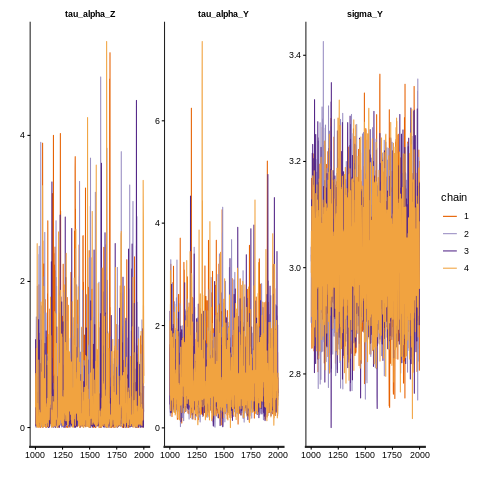

In [ ]:
%%R
rds_url <- "https://raw.githubusercontent.com/EvanDelcamp/mlb-draft-war-project/main/fit_two_part_hier.rds"

download.file(rds_url, destfile = "fit_two_part_hier.rds", mode = "wb")

fit_2part <- readRDS("fit_two_part_hier.rds")


# Quick diagnostics
print(fit_2part, pars = c("beta_Z","beta_Y","sigma_Y","mu_alpha_Z","tau_alpha_Z","mu_alpha_Y","tau_alpha_Y"))
rstan::check_hmc_diagnostics(fit_2part)

# traceplots (keep a few key params)
traceplot(fit_2part, pars = c("tau_alpha_Z","tau_alpha_Y","sigma_Y"))


In [ ]:
%%R
# This loads the fit from my drive. Do not need to run this unless
# the model has changed.
# Load fit
# fit_2part <- readRDS(
#  "/content/drive/MyDrive/Data Science 551 MLB Draft WAR Final Project/fit_two_part_hier.rds"
# )

# Load fit from rds file on github instead:


# Quick diagnostics
# print(fit_2part, pars = c("beta_Z","beta_Y","sigma_Y","mu_alpha_Z","tau_alpha_Z","mu_alpha_Y","tau_alpha_Y"))
# rstan::check_hmc_diagnostics(fit_2part)

# traceplots (keep a few key params)
# traceplot(fit_2part, pars = c("tau_alpha_Z","tau_alpha_Y","sigma_Y"))

### 7. Model Checking. Note: Cells were numbered just for cleanup and looking for redundancies.

In [ ]:
%%R
# CELL 2
## checking for divergences
sampler_params <- get_sampler_params(fit_2part, inc_warmup = FALSE)
total_div <- sum(sapply(sampler_params, function(x) sum(x[, "divergent__"])))
total_div


[1] 0


In [ ]:
%%R
# CELL 3
# 1) Subset to years with rank info and build rank_score
df_used_war <- df_clean %>%
  filter(year %in% c(2017, 2018)) %>%
  mutate(
    ranked     = !is.na(rank),
    rank_score = if_else(ranked, 201 - rank + 1, 0),
    ranked     = as.integer(ranked),

    # year factor & index for hierarchy
    draft_year_factor = factor(year),
    year_id = as.integer(draft_year_factor)
  ) %>%
  select(
    person_id,
    person_full_name,
    WAR_7yr,
    reached_mlb_7yr,
    year_id,
    school_type_3cat,
    is_pitcher,
    age_c,
    bat_side,
    throw_hand,
    ranked,
    rank_score
  ) %>%
  drop_na()

In [ ]:
%%R
# CELL 4
# Canonical model inputs: always use the Stan data list
stan_X       <- stan_data_2part_hier$X
stan_year_id <- stan_data_2part_hier$year_id
stan_z       <- stan_data_2part_hier$z
stan_y       <- stan_data_2part_hier$y

N <- nrow(stan_X)
K <- ncol(stan_X)
T <- stan_data_2part_hier$T

# Posterior draws
draw <- rstan::extract(fit_2part)
S <- length(draw$sigma_Y)

# add player labels, make sure row-order matches:
stopifnot(nrow(df_used_war) == N)
stopifnot(all(df_used_war$year_id == stan_year_id))
stopifnot(all(df_used_war$reached_mlb_7yr == stan_z))
stopifnot(all(df_used_war$WAR_7yr == stan_y))


In [ ]:
%%R
# CELL 5
# Summaries by player
# mu_war = posterior draws of E[WAR | reach] (S_keep x N)

library(matrixStats)
# Optional thinning for speed
set.seed(321)
S_keep <- min(S, 2000)
keep <- sample.int(S, S_keep)

beta_Zk  <- draw$beta_Z[keep, , drop=FALSE]
alpha_Zk <- draw$alpha_Z[keep, , drop=FALSE]
beta_Yk  <- draw$beta_Y[keep, , drop=FALSE]
alpha_Yk <- draw$alpha_Y[keep, , drop=FALSE]

# S_keep x N
eta_Z <- t(stan_X %*% t(beta_Zk)) + alpha_Zk[, stan_year_id]
p_reach <- plogis(eta_Z)

mu_war <- t(stan_X %*% t(beta_Yk)) + alpha_Yk[, stan_year_id]

# Unconditional expected WAR
ewar <- p_reach * mu_war

# Summaries by player
player_summ <- data.frame(
  row_id   = 1:N,
  year_id  = stan_year_id,
  p_mean   = colMeans(p_reach),
  p_med    = colMedians(p_reach),
  p_lo90   = colQuantiles(p_reach, probs = 0.05),
  p_hi90   = colQuantiles(p_reach, probs = 0.95),
  ewar_mean= colMeans(ewar),
  ewar_med = colMedians(ewar),
  ewar_lo90= colQuantiles(ewar, probs = 0.05),
  ewar_hi90= colQuantiles(ewar, probs = 0.95)
)

# Add labels
player_summ$person_id <- df_used_war$person_id
player_summ$name <- df_used_war$person_full_name

head(player_summ)


  row_id year_id     p_mean      p_med     p_lo90     p_hi90  ewar_mean
1      1       1 0.07168249 0.07055344 0.05367203 0.09281369 0.04654507
2      2       1 0.13259774 0.13177931 0.09882810 0.16830454 0.04430238
3      3       1 0.09069243 0.08931798 0.06722481 0.11946973 0.02330692
4      4       1 0.09121731 0.08981220 0.06776547 0.11985700 0.02366073
5      5       1 0.10537955 0.10466341 0.08018103 0.13381553 0.08184143
6      6       2 0.08569491 0.08441011 0.06171910 0.11391331 0.10015811
    ewar_med    ewar_lo90  ewar_hi90 person_id          name
1 0.04569007 -0.001658276 0.10025280    599697    Cam Warner
2 0.04369137 -0.052303541 0.14366344    608326  Troy Conyers
3 0.02234434 -0.041127283 0.09257104    608363   Jared Price
4 0.02278275 -0.040875753 0.09304889    608367   C.J. Saylor
5 0.07890356  0.009360851 0.16273168    615696   Jake Lumley
6 0.09766553  0.033760317 0.17652761    621051 Steven Wilson


In [ ]:
%%R
# CELL 6
# Coefficient summary table
design_terms <- colnames(stan_X)

betaZ_s <- summary(fit_2part, pars = "beta_Z")$summary
betaZ_table <- data.frame(term = design_terms, betaZ_s, row.names = NULL)
print(betaZ_table)


                      term        mean      se_mean          sd        X2.5.
1              (Intercept) -2.09187086 1.757925e-02 0.904393816 -3.781330650
2  school_type_3catCollege  1.23642388 5.879929e-03 0.295992558  0.649631174
3     school_type_3catJUCO  0.70257988 5.268701e-03 0.304831648  0.111982604
4           is_pitcherTRUE  0.36213948 1.942601e-03 0.127322317  0.118705441
5                    age_c -0.02274267 1.350048e-04 0.006770643 -0.035787496
6                bat_sideL  0.16611727 2.710468e-03 0.159759306 -0.139809073
7                bat_sideS  0.13524614 4.220816e-03 0.329590587 -0.523768418
8              throw_handL  0.12089553 3.000516e-03 0.182338392 -0.240604684
9                   ranked  0.48934580 3.620818e-03 0.249095891 -0.006523567
10              rank_score  0.01405878 3.082272e-05 0.002064952  0.010122096
           X25.        X50.        X75.       X97.5.    n_eff      Rhat
1  -2.704072408 -2.13708488 -1.48634959 -0.229933019 2646.759 1.0000229
2   1.034

In [ ]:
%%R
# Freeze the draw subset used for PPC so later code can't accidentally change it
keep_ppc <- keep
S_keep_ppc <- length(keep_ppc)

In [ ]:
%%R
# CELL 7
## PPC Checking - Model reproduces overall reach rate well.
set.seed(321)

eta_Z_ppc <- t(stan_X %*% t(draw$beta_Z[keep_ppc, , drop=FALSE])) +
  draw$alpha_Z[keep_ppc, stan_year_id]
p_ppc <- plogis(eta_Z_ppc)

z_rep <- matrix(rbinom(S_keep_ppc * N, 1, as.vector(p_ppc)), nrow = S_keep_ppc)

obs_rate <- mean(stan_z)
rep_rates <- rowMeans(z_rep)

c(obs = obs_rate,
  rep_p05 = quantile(rep_rates, 0.05),
  rep_p50 = quantile(rep_rates, 0.50),
  rep_p95 = quantile(rep_rates, 0.95))



        obs  rep_p05.5% rep_p50.50% rep_p95.95% 
  0.1803140   0.1637463   0.1803140   0.1977090 


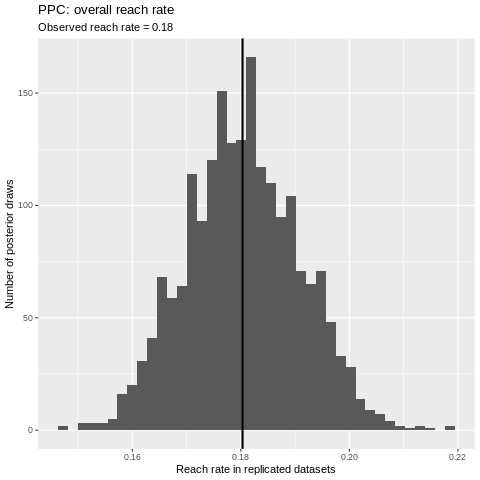

In [ ]:
%%R
# CELL 8
# Graphical PPC checking for reaching mlb
library(ggplot2)

df_rate <- data.frame(rep_rate = rep_rates)

ggplot(df_rate, aes(x = rep_rate)) +
  geom_histogram(bins = 40) +
  geom_vline(xintercept = obs_rate, linewidth = 1) +
  labs(
    x = "Reach rate in replicated datasets",
    y = "Number of posterior draws",
    title = "PPC: overall reach rate",
    subtitle = paste0("Observed reach rate = ", round(obs_rate, 3))
  )


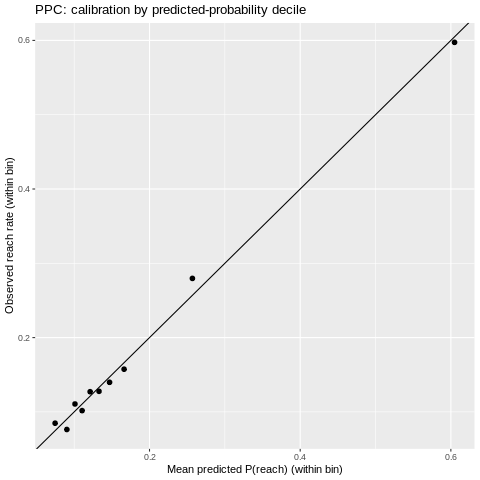

In [ ]:
%%R
# CELL 10
# More reach MLB posterior probability checking
# Model probablities look well calibrated
# p_ppc is S_keep x N; take posterior mean predicted probability per player
p_hat <- colMeans(p_ppc)

df_cal <- data.frame(p_hat = p_hat, z_obs = stan_z)

# Make decile bins by predicted probability
df_cal$bin <- cut(
  df_cal$p_hat,
  breaks = quantile(df_cal$p_hat, probs = seq(0, 1, 0.1)),
  include.lowest = TRUE
)

cal_tab <- aggregate(cbind(z_obs, p_hat) ~ bin, data = df_cal, FUN = mean)
names(cal_tab) <- c("bin", "obs_reach_rate", "mean_pred_p")

ggplot(cal_tab, aes(x = mean_pred_p, y = obs_reach_rate)) +
  geom_point(size = 2) +
  geom_abline(slope = 1, intercept = 0) +
  labs(
    x = "Mean predicted P(reach) (within bin)",
    y = "Observed reach rate (within bin)",
    title = "PPC: calibration by predicted-probability decile"
  )


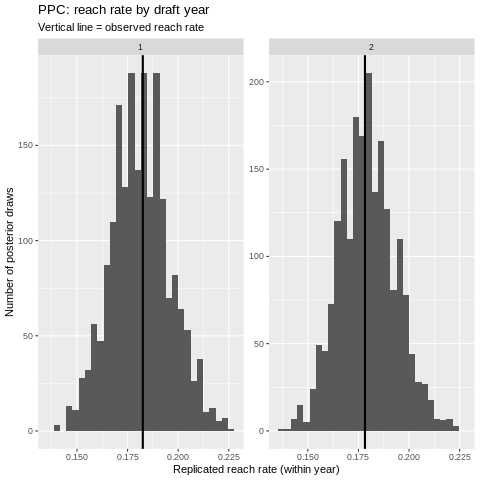

In [ ]:
%%R
# CELL 11
# Replicated rates within each year look okay
obs_by_year <- tapply(stan_z, stan_year_id, mean)
rep_by_year <- sapply(1:T, function(t) rowMeans(z_rep[, stan_year_id == t, drop=FALSE]))

df_year <- data.frame(
  year_id = factor(rep(1:T, each = S_keep)),
  rep_rate = as.vector(rep_by_year)
)

ggplot(df_year, aes(x = rep_rate)) +
  geom_histogram(bins = 30) +
  facet_wrap(~ year_id, scales = "free_y") +
  geom_vline(data = data.frame(year_id=factor(1:T), obs=as.numeric(obs_by_year)),
             aes(xintercept = obs), linewidth = 1) +
  labs(
    x = "Replicated reach rate (within year)",
    y = "Number of posterior draws",
    title = "PPC: reach rate by draft year",
    subtitle = "Vertical line = observed reach rate"
  )


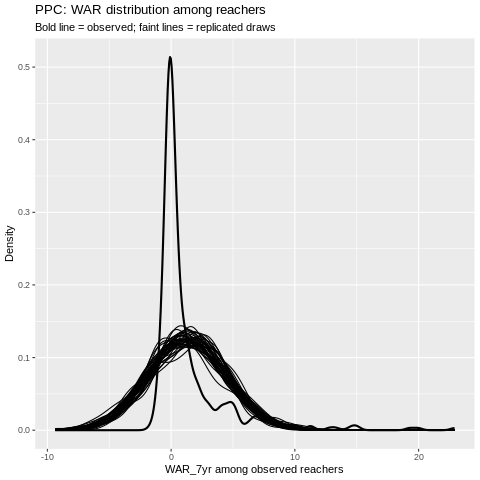

In [ ]:
# Posterior prediction with normal likelihood doesnt match the near 0 pile up super well.
# CELL 13
%%R
set.seed(321)
idx_reach <- which(stan_z == 1)

mu_ppc <- t(stan_X %*% t(draw$beta_Y[keep_ppc, , drop=FALSE])) +
  draw$alpha_Y[keep_ppc, stan_year_id]
sigma_ppc <- draw$sigma_Y[keep_ppc]

eps <- matrix(rnorm(S_keep_ppc * N), nrow = S_keep_ppc, ncol = N)
yrep <- mu_ppc + sweep(eps, 1, sigma_ppc, `*`)

y_obs_reach <- stan_y[idx_reach]
yrep_reach  <- yrep[, idx_reach, drop=FALSE]

# Overlay a handful of predictive densities
set.seed(321)
draw_ids <- sample(1:S_keep, size = 40)

df_obs <- data.frame(war = y_obs_reach, type = "Observed")
df_rep <- do.call(rbind, lapply(draw_ids, function(s) {
  data.frame(war = yrep_reach[s, ], draw = s)
}))

ggplot() +
  geom_density(data = df_rep, aes(x = war, group = draw), alpha = 0.12) +
  geom_density(data = df_obs, aes(x = war), linewidth = 1) +
  labs(
    x = "WAR_7yr among observed reachers",
    y = "Density",
    title = "PPC: WAR distribution among reachers",
    subtitle = "Bold line = observed; faint lines = replicated draws"
  )

# ggsave("ppc_war_reachers.png", width = 6.5, height = 4.0, dpi = 300)



In [ ]:
%%R
# CELL 14
# This confirms that the distribution of WAR | Reach has a different distribution but that we are covering the intervals well
idx_reach <- which(stan_z == 1)
y_reach <- stan_y[idx_reach]

c(
  prop_exact_zero = mean(y_reach == 0),
  prop_under_0p5  = mean(y_reach < 0.5),
  prop_under_1    = mean(y_reach < 1),
  min_war         = min(y_reach),
  q05             = quantile(y_reach, 0.05),
  median          = median(y_reach),
  q95             = quantile(y_reach, 0.95),
  max_war         = max(y_reach)
)


prop_exact_zero  prop_under_0p5    prop_under_1         min_war          q05.5% 
    0.002352941     0.602352941     0.682352941    -1.634400000    -0.743740000 
         median         q95.95%         max_war 
    0.185100000     7.232920000    22.905100000 


In [ ]:
%%R
# CELL 15
# A quantile-based PPC is consistent with this mismatch: the observed median WAR among reachers is 0.19,
# while replicated datasets place the median between 0.94 and 1.73, and the model produces an unrealistically
# negative lower tail (replicated 5th percentile $\approx [-4.4,-3.1]$ vs. observed $-0.74$).

set.seed(321)

idx_reach <- which(stan_z == 1)

mu_ppc <- t(stan_X %*% t(draw$beta_Y[keep_ppc, , drop=FALSE])) +
  draw$alpha_Y[keep_ppc, stan_year_id]
sigma_ppc <- draw$sigma_Y[keep_ppc]

eps <- matrix(rnorm(S_keep_ppc * N), nrow = S_keep_ppc, ncol = N)
y_rep <- mu_ppc + sweep(eps, 1, sigma_ppc, `*`)

# Observed quantiles among reachers
obs_q <- quantile(stan_y[idx_reach], c(0.05, 0.5, 0.95))

# Replicated quantiles among reachers, for each draw
rep_q <- t(apply(y_rep[, idx_reach, drop=FALSE], 1, quantile, probs = c(0.05, 0.5, 0.95)))

# Posterior predictive interval for each quantile (across draws)
rep_q_ci <- apply(rep_q, 2, quantile, probs = c(0.05, 0.5, 0.95))
colnames(rep_q_ci) <- c("q05", "q50", "q95")
rownames(rep_q_ci) <- c("ppc_5%", "ppc_50%", "ppc_95%")

list(observed = obs_q, replicated_interval = rep_q_ci)


$observed
      5%      50%      95% 
-0.74374  0.18510  7.23292 

$replicated_interval
         
                q05       q50      q95
  ppc_5%  -4.409670 0.9409987 5.800130
  ppc_50% -3.726305 1.3404301 6.418343
  ppc_95% -3.112743 1.7278942 7.057756



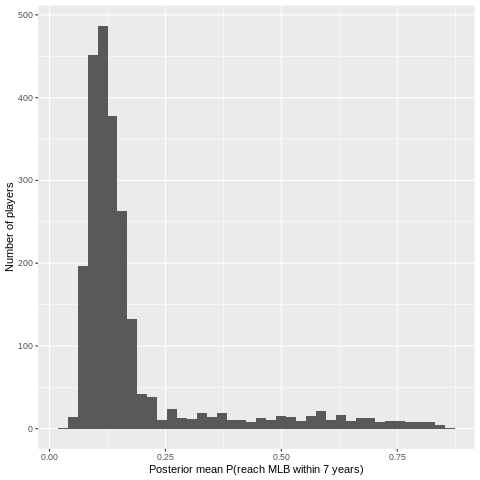

In [ ]:
%%R
# CELL 24
# Across all players in the dataset, what does the distribution of predicted probability of reaching MLB within 7 years look like?
# The distribution of posterior mean reach probabilities is highly right-skewed,
# with most players concentrated at low values and a small tail of high-probability prospects, reflecting the steep attrition from draft selection to MLB debut.
# interesting that few players in the middle.
# Overall distribution of reach probabilities
ggplot(player_summ, aes(x = p_mean)) +
  geom_histogram(bins = 40) +
  labs(x = "Posterior mean P(reach MLB within 7 years)", y = "Number of players")


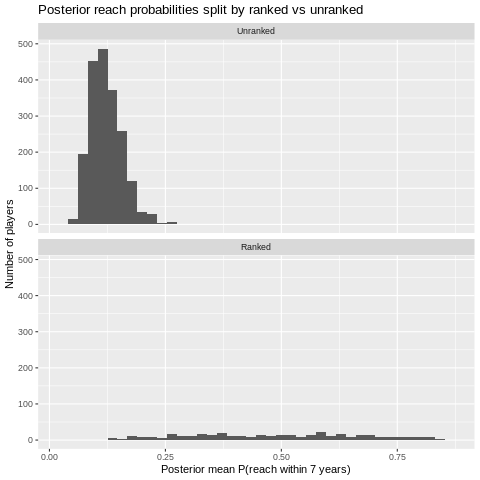

In [ ]:
%%R
# Review the posterior reach MLB split by ranked and unranked
library(ggplot2)

df_p <- data.frame(
  p_mean  = player_summ$p_mean,
  ranked  = factor(df_used_war$ranked, levels = c(0,1), labels = c("Unranked", "Ranked"))
)

ggplot(df_p, aes(x = p_mean)) +
  geom_histogram(bins = 40) +
  facet_wrap(~ ranked, ncol = 1) +
  labs(
    x = "Posterior mean P(reach within 7 years)",
    y = "Number of players",
    title = "Posterior reach probabilities split by ranked vs unranked"
  )


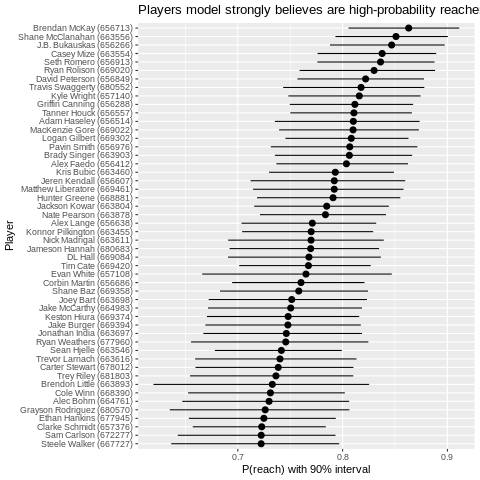

In [ ]:
%%R
# CELL 26
library(ggplot2)

topN <- 50
top_players <- player_summ[order(-player_summ$p_mean), ][1:topN, ]

top_players$label <- factor(
  paste0(top_players$name, " (", top_players$person_id, ")"),
  levels = rev(paste0(top_players$name, " (", top_players$person_id, ")"))
)

ggplot(top_players, aes(x = label, y = p_mean)) +
  geom_pointrange(aes(ymin = p_lo90, ymax = p_hi90)) +
  coord_flip() +
  labs(x = "Player", y = "P(reach) with 90% interval",
       title = paste0("Players model strongly believes are high-probability reachers."))


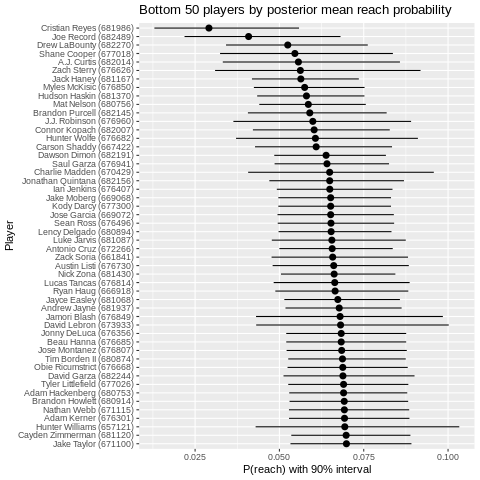

In [ ]:
%%R
# CELL 27
#Players least likely to reach MLB
library(ggplot2)

bottomN <- 50
bottom_players <- player_summ[order(player_summ$p_mean), ][1:bottomN, ]

# Put the lowest probabilities at the top after coord_flip()
bottom_players$label <- paste0(bottom_players$name, " (", bottom_players$person_id, ")")
bottom_players$label <- factor(bottom_players$label, levels = rev(bottom_players$label))

ggplot(bottom_players, aes(x = label, y = p_mean)) +
  geom_pointrange(aes(ymin = p_lo90, ymax = p_hi90)) +
  coord_flip() +
  labs(
    x = "Player",
    y = "P(reach) with 90% interval",
    title = paste0("Bottom ", bottomN, " players by posterior mean reach probability")
  )



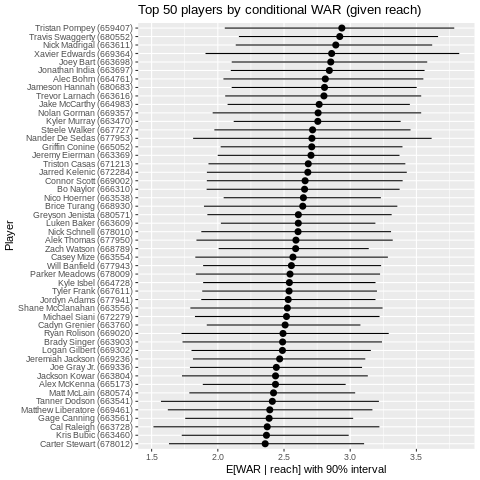

In [ ]:
%%R
# CELL 28
# Answers If they make MLB, how good are they expected to be?
library(matrixStats)
library(ggplot2)

# mu_war is S x N (from your earlier code)
mu_mean <- colMeans(mu_war)
mu_lo90 <- colQuantiles(mu_war, probs = 0.05)
mu_hi90 <- colQuantiles(mu_war, probs = 0.95)

war_given_reach_summ <- data.frame(
  person_id = df_used_war$person_id,
  name      = df_used_war$person_full_name,
  year_id   = stan_year_id,
  mu_mean   = mu_mean,
  mu_lo90   = mu_lo90,
  mu_hi90   = mu_hi90
)

# Top 50 by conditional mean WAR
topN <- 50
top_mu <- war_given_reach_summ[order(-war_given_reach_summ$mu_mean), ][1:topN, ]
top_mu$label <- factor(paste0(top_mu$name, " (", top_mu$person_id, ")"),
                       levels = rev(paste0(top_mu$name, " (", top_mu$person_id, ")")))

ggplot(top_mu, aes(x = label, y = mu_mean)) +
  geom_pointrange(aes(ymin = mu_lo90, ymax = mu_hi90)) +
  coord_flip() +
  labs(x="Player", y="E[WAR | reach] with 90% interval",
       title=paste0("Top ", topN, " players by conditional WAR (given reach)"))


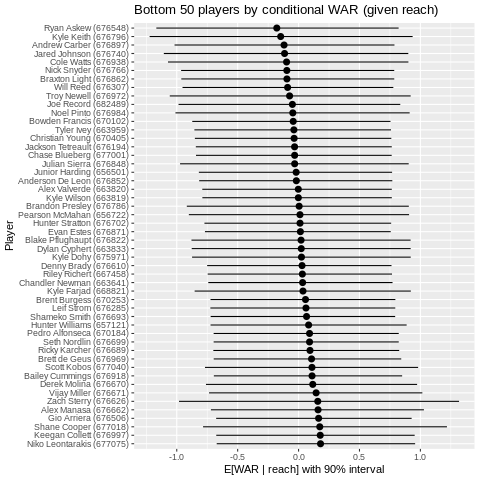

In [ ]:
%%R
# CELL 29
library(matrixStats)
library(ggplot2)

# mu_war is S_keep x N
mu_mean <- colMeans(mu_war)
mu_lo90 <- colQuantiles(mu_war, probs = 0.05)
mu_hi90 <- colQuantiles(mu_war, probs = 0.95)

war_given_reach_summ <- data.frame(
  person_id = df_used_war$person_id,
  name      = df_used_war$person_full_name,
  year_id   = df_used_war$year_id,
  mu_mean   = mu_mean,
  mu_lo90   = mu_lo90,
  mu_hi90   = mu_hi90
)

# Bottom 50 by conditional mean WAR
bottomN <- 50
bottom_mu <- war_given_reach_summ[order(war_given_reach_summ$mu_mean), ][1:bottomN, ]

bottom_mu$label <- factor(
  paste0(bottom_mu$name, " (", bottom_mu$person_id, ")"),
  levels = rev(paste0(bottom_mu$name, " (", bottom_mu$person_id, ")"))
)

ggplot(bottom_mu, aes(x = label, y = mu_mean)) +
  geom_pointrange(aes(ymin = mu_lo90, ymax = mu_hi90)) +
  coord_flip() +
  labs(x="Player", y="E[WAR | reach] with 90% interval",
       title=paste0("Bottom ", bottomN, " players by conditional WAR (given reach)"))


In [ ]:
%%R
# CELL 30
library(rstan)

post <- rstan::extract(fit_2part)

# These names match your two-part Stan file
beta_Y  <- post$beta_Y    # S x K
alpha_Y <- post$alpha_Y   # S x T
sigma_Y <- post$sigma_Y   # length S

X       <- stan_data_2part_hier$X        # N x K
year_id <- stan_data_2part_hier$year_id  # length N
N <- nrow(X)
S <- nrow(beta_Y)

# (Optional) thin draws to keep memory reasonable
set.seed(321)
S_keep <- min(S, 2000)
keep <- sample.int(S, S_keep)

beta_Yk  <- beta_Y[keep, , drop=FALSE]
alpha_Yk <- alpha_Y[keep, , drop=FALSE]
sigma_k  <- sigma_Y[keep]

# Posterior draws of conditional mean WAR: mu_war is S_keep x N
mu_war <- t(X %*% t(beta_Yk)) + alpha_Yk[, year_id]

# Posterior predictive WAR given reach:
# add draw-specific noise with SD = sigma_k
set.seed(321)
yrep_given_reach <- mu_war + matrix(
  rnorm(S_keep * N, mean = 0, sd = rep(sigma_k, times = N)),
  nrow = S_keep, ncol = N
)

dim(yrep_given_reach)  # should be S_keep x N


[1] 2000 2357


In [ ]:
%%R
# CELL 31
# Find Nico's index in your df_used_war (adjust matching if needed)
idx_nico <- which(df_used_war$person_full_name == "Nico Hoerner")[1]

# Posterior predictive WAR given reach: yrep_given_reach is S x N
# (from the code where you added sigma_Y noise)
prob_over_2 <- mean(yrep_given_reach[, idx_nico] > 2)

prob_over_2


[1] 0.58


In [ ]:
%%R
# CELL 32
library(matrixStats)

# 1) This matches the chart: posterior for mu_i = E[WAR | reach]
mu_i <- mu_war[, idx_nico]
c(mu_mean = mean(mu_i),
  mu_q05  = quantile(mu_i, 0.05),
  mu_q50  = quantile(mu_i, 0.50),
  mu_q95  = quantile(mu_i, 0.95))

# 2) Residual SD that drives how often realized WAR falls below/above 2
c(sigma_mean = mean(sigma_k),
  sigma_q05  = quantile(sigma_k, 0.05),
  sigma_q50  = quantile(sigma_k, 0.50),
  sigma_q95  = quantile(sigma_k, 0.95))


   sigma_mean  sigma_q05.5% sigma_q50.50% sigma_q95.95% 
     3.020481      2.859596      3.016758      3.200455 


In [ ]:
%%R
# CELL 33
# Per-draw probability P(WAR > 2 | mu, sigma) under Normal
p_over2_draw <- 1 - pnorm(2, mean = mu_war[, idx_nico], sd = sigma_k)

mean(p_over2_draw)


[1] 0.5842857


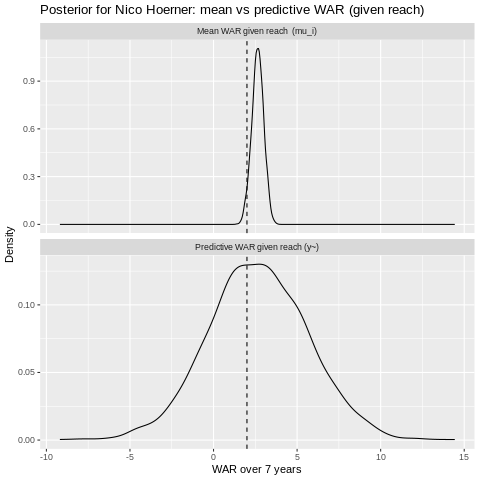

In [ ]:
%%R
# CELL 34
library(ggplot2)

# Choose player
name_target <- "Nico Hoerner"
idx <- which(df_used_war$person_full_name == name_target)[1]

# Draws for conditional mean and predictive WAR given reach
mu_draws   <- mu_war[, idx]
yrep_draws <- yrep_given_reach[, idx]

df_one <- rbind(
  data.frame(value = mu_draws,   type = "Mean WAR given reach  (mu_i)"),
  data.frame(value = yrep_draws, type = "Predictive WAR given reach (y~)")
)

ggplot(df_one, aes(x = value)) +
  geom_density() +
  geom_vline(xintercept = 2, linetype = "dashed") +
  facet_wrap(~type, ncol = 1, scales = "free_y") +
  labs(
    x = "WAR over 7 years",
    y = "Density",
    title = paste0("Posterior for ", name_target, ": mean vs predictive WAR (given reach)")
  )


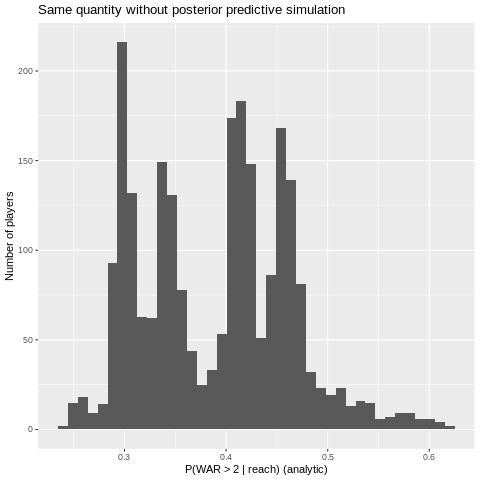

In [ ]:
%%R
# CELL 36
# Calculate using normal likelihood
p_over2_analytic <- colMeans(1 - pnorm(2, mean = mu_war, sd = sigma_k))

ggplot(data.frame(p = p_over2_analytic), aes(x = p)) +
  geom_histogram(bins = 40) +
  labs(x = "P(WAR > 2 | reach) (analytic)", y = "Number of players",
       title = "Same quantity without posterior predictive simulation")


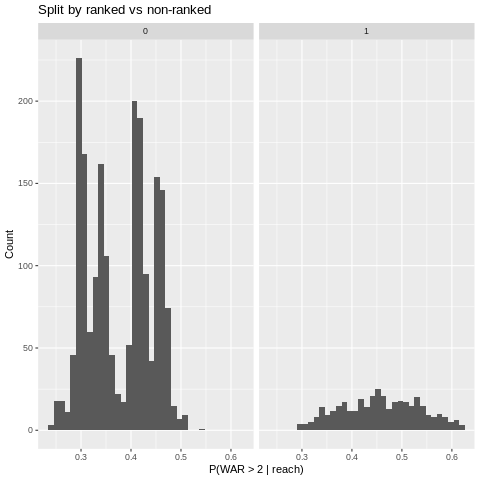

In [ ]:
# Interesting that the above is bimodal! Lets check into why:
%%R
# CELL 37
df_prob <- data.frame(
  p_over2 = p_over2_analytic,
  is_pitcher = df_used_war$is_pitcher,
  ranked = df_used_war$ranked,
  year_id = df_used_war$year_id
)

ggplot(df_prob, aes(x = p_over2)) +
  geom_histogram(bins = 35) +
  facet_wrap(~ ranked) +
  labs(x = "P(WAR > 2 | reach)", y = "Count", title = "Split by ranked vs non-ranked")

# So non ranked is bi modal, but ranked is not as much.

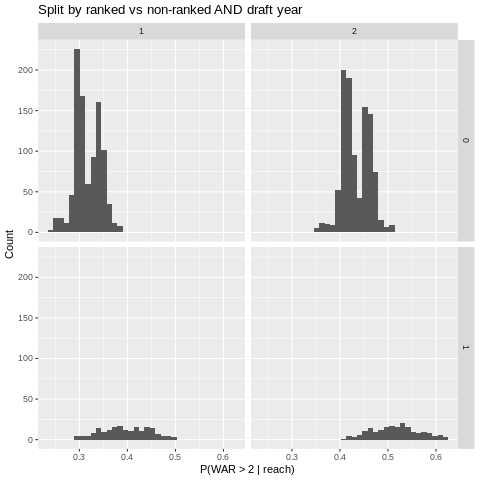

In [ ]:
%%R
# Check year
# CELL38
ggplot(df_prob, aes(x = p_over2)) +
  geom_histogram(bins = 35) +
  facet_grid(ranked ~ year_id) +
  labs(x = "P(WAR > 2 | reach)", y = "Count",
       title = "Split by ranked vs non-ranked AND draft year")


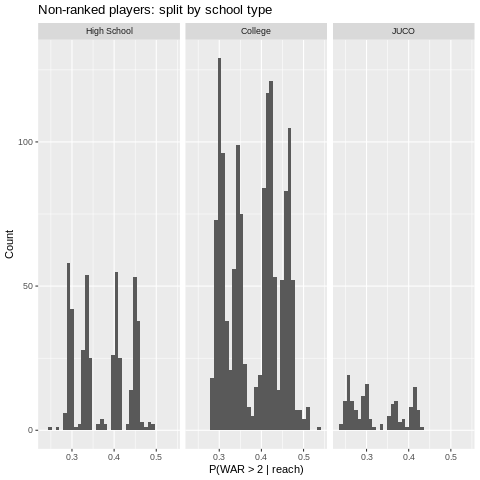

In [ ]:
%%R
# CELL 39
df_prob <- data.frame(
  p_over2 = p_over2_analytic,
  ranked = df_used_war$ranked,
  is_pitcher = df_used_war$is_pitcher,
  year_id = df_used_war$year_id,
  school_type_3cat = df_used_war$school_type_3cat
)

df_nonrank <- subset(df_prob, ranked == 0)

library(ggplot2)
ggplot(df_nonrank, aes(x = p_over2)) +
  geom_histogram(bins = 35) +
  facet_wrap(~ school_type_3cat) +
  labs(
    x = "P(WAR > 2 | reach)",
    y = "Count",
    title = "Non-ranked players: split by school type"
  )


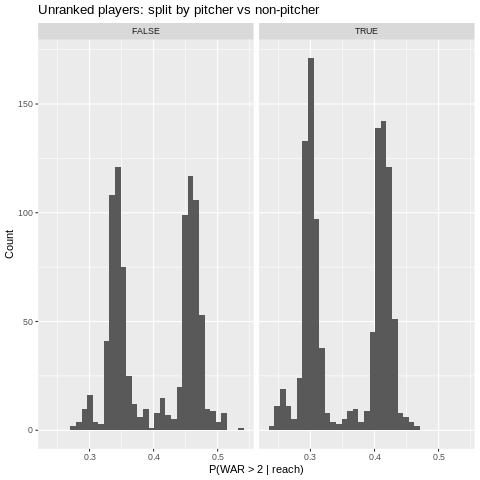

In [ ]:
%%R
# CELL 40
# Is it by is Pitcher or not for unranked?

df_nonrank <- subset(df_prob, ranked == 0)

ggplot(df_nonrank, aes(x = p_over2)) +
  geom_histogram(bins = 35) +
  facet_wrap(~ is_pitcher) +
  labs(
    x = "P(WAR > 2 | reach)",
    y = "Count",
    title = "Unranked players: split by pitcher vs non-pitcher"
  )


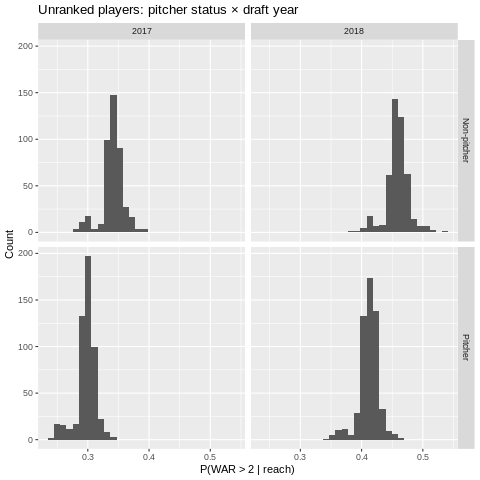

In [ ]:
%%R
# CELL 41
# Computing P( WAR > 2 | reach) from posterior predictive (analytically)
df_prob$draft_year <- factor(df_prob$year_id,
                            levels = c(1,2),
                            labels = c("2017","2018"))

df_prob$is_pitcher_label <- factor(df_prob$is_pitcher,
                                   levels = c(FALSE, TRUE),
                                   labels = c("Non-pitcher", "Pitcher"))

ggplot(subset(df_prob, ranked == 0), aes(x = p_over2)) +
  geom_histogram(bins = 30) +
  facet_grid(is_pitcher_label ~ draft_year) +
  labs(
    x = "P(WAR > 2 | reach)",
    y = "Count",
    title = "Unranked players: pitcher status × draft year"
  )


In [ ]:
%%R
# CELL 42
aggregate(p_over2 ~ ranked + is_pitcher + year_id, data = df_prob, mean)


  ranked is_pitcher year_id   p_over2
1      0      FALSE       1 0.3408374
2      1      FALSE       1 0.4246951
3      0       TRUE       1 0.2976019
4      1       TRUE       1 0.3712655
5      0      FALSE       2 0.4582934
6      1      FALSE       2 0.5450034
7      0       TRUE       2 0.4123376
8      1       TRUE       2 0.4931791


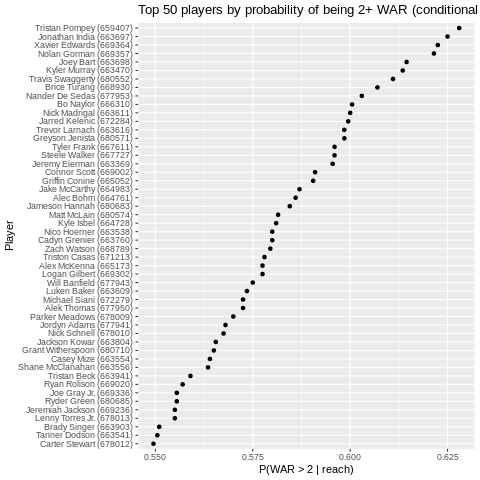

In [ ]:
%%R
# CELL 43
warprod <- data.frame(
  person_id = df_used_war$person_id,
  name      = df_used_war$person_full_name,
  p_over2   = colMeans(yrep_given_reach > 2)
)

topN <- 50
top_prod <- warprod[order(-warprod$p_over2), ][1:topN, ]
top_prod$label <- factor(paste0(top_prod$name, " (", top_prod$person_id, ")"),
                         levels = rev(paste0(top_prod$name, " (", top_prod$person_id, ")")))

ggplot(top_prod, aes(x = label, y = p_over2)) +
  geom_point() +
  coord_flip() +
  labs(
    x = "Player",
    y = "P(WAR > 2 | reach)",
    title = paste0("Top ", topN, " players by probability of being 2+ WAR (conditional on reaching)")
  )


In [ ]:
%%R
# Cell 44: Calculate Unconditional WAR overall:
# Unconditional expected WAR per player (posterior): E[WAR] = p * mu

etaZ  <- t(stan_X %*% t(draw$beta_Z[keep,,drop=FALSE])) + draw$alpha_Z[keep, stan_year_id]
p_mat <- plogis(etaZ)  # S_keep x N

mu_mat <- t(stan_X %*% t(draw$beta_Y[keep,,drop=FALSE])) + draw$alpha_Y[keep, stan_year_id]  # S_keep x N

ewar_mat <- p_mat * mu_mat  # S_keep x N

# Convert year_id (1/2) to real years (2017/2018)
draft_year <- factor(stan_year_id, levels = c(1,2), labels = c("2017","2018"))

ewar_summ <- data.frame(
  person_id = df_used_war$person_id,
  name      = df_used_war$person_full_name,
  draft_year= draft_year,
  ewar_mean = colMeans(ewar_mat),
  ewar_lo90 = matrixStats::colQuantiles(ewar_mat, probs = 0.05),
  ewar_hi90 = matrixStats::colQuantiles(ewar_mat, probs = 0.95)
)

head(ewar_summ[order(-ewar_summ$ewar_mean), ], 10)


     person_id             name draft_year ewar_mean ewar_lo90 ewar_hi90
1698    680552 Travis Swaggerty       2018  2.387959  1.756277  3.031385
376     663611    Nick Madrigal       2018  2.225416  1.616035  2.833535
1706    680683   Jameson Hannah       2018  2.158872  1.583134  2.731958
357     663554       Casey Mize       2018  2.150280  1.531776  2.765322
359     663556 Shane McClanahan       2018  2.148281  1.523508  2.778735
403     663698        Joey Bart       2018  2.143646  1.543335  2.750150
402     663697   Jonathan India       2018  2.120907  1.527870  2.717191
516     664983    Jake McCarthy       2018  2.075100  1.520076  2.628150
380     663616   Trevor Larnach       2018  2.073341  1.498814  2.656344
675     669020     Ryan Rolison       2018  2.068257  1.428738  2.734762


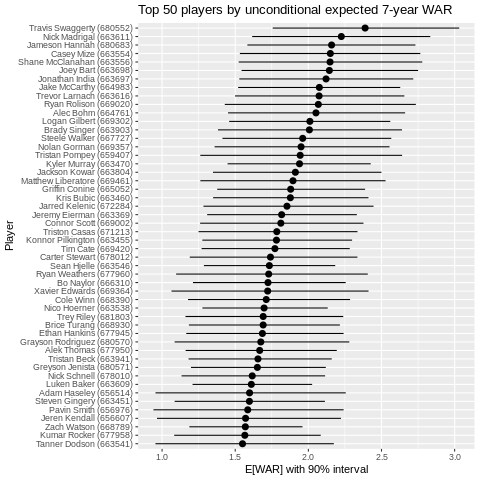

In [ ]:
%%R
library(ggplot2)

topN <- 50
top_ewar <- ewar_summ[order(-ewar_summ$ewar_mean), ][1:topN, ]
top_ewar$label <- factor(paste0(top_ewar$name, " (", top_ewar$person_id, ")"),
                         levels = rev(paste0(top_ewar$name, " (", top_ewar$person_id, ")")))

ggplot(top_ewar, aes(x = label, y = ewar_mean)) +
  geom_pointrange(aes(ymin = ewar_lo90, ymax = ewar_hi90)) +
  coord_flip() +
  labs(x = "Player", y = "E[WAR] with 90% interval",
       title = paste0("Top ", topN, " players by unconditional expected 7-year WAR"))


In [ ]:
%%R
library(dplyr)
library(matrixStats)
library(ggplot2)

# Posterior summaries per player
ewar_mean <- colMeans(ewar_mat)
ewar_lo90 <- colQuantiles(ewar_mat, probs = 0.05)
ewar_hi90 <- colQuantiles(ewar_mat, probs = 0.95)

df_ewar <- df_used_war %>%
  mutate(
    ewar_mean = ewar_mean,
    ewar_lo90 = ewar_lo90,
    ewar_hi90 = ewar_hi90,
    role = if_else(is_pitcher == 1, "Pitcher", "Hitter"),
    ranked_lab = if_else(ranked == 1, "Ranked", "Unranked")
  )

# Group summary (posterior means summarized across players)
group_tab <- df_ewar %>%
  group_by(school_type_3cat, role, ranked_lab) %>%
  summarize(
    n = n(),
    mean_ewar = mean(ewar_mean),
    median_ewar = median(ewar_mean),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_ewar))

group_tab


# A tibble: 12 × 6
   school_type_3cat role    ranked_lab     n mean_ewar median_ewar
   <fct>            <chr>   <chr>      <int>     <dbl>       <dbl>
 1 College          Hitter  Ranked        90    1.01        0.895 
 2 College          Pitcher Ranked       111    0.880       0.756 
 3 High School      Hitter  Ranked        81    0.828       0.773 
 4 High School      Pitcher Ranked        85    0.763       0.661 
 5 JUCO             Hitter  Ranked         2    0.604       0.604 
 6 JUCO             Pitcher Ranked         7    0.437       0.413 
 7 College          Hitter  Unranked     599    0.142       0.135 
 8 College          Pitcher Unranked     784    0.140       0.135 
 9 High School      Hitter  Unranked     228    0.0989      0.0995
10 High School      Pitcher Unranked     220    0.0938      0.0743
11 JUCO             Hitter  Unranked      73    0.0829      0.0681
12 JUCO             Pitcher Unranked      77    0.0546      0.0174


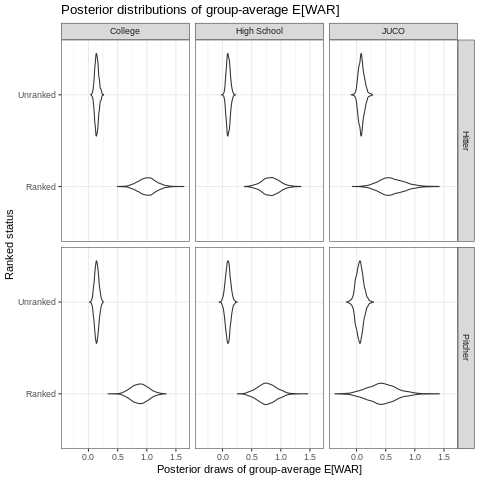

In [ ]:
%%R
library(dplyr)
library(ggplot2)
library(matrixStats)

# Assumes:
# ewar_mat is S_keep x N (posterior draws of unconditional expected WAR per player)
# df_used_war has N rows in the SAME order as columns of ewar_mat

N <- nrow(df_used_war)
stopifnot(ncol(ewar_mat) == N)

df_groups <- df_used_war %>%
  transmute(
    row_id = row_number(),
    school_type_3cat,
    role = if_else(is_pitcher == 1, "Pitcher", "Hitter"),
    ranked_lab = if_else(ranked == 1, "Ranked", "Unranked")
  )

# Indices of players per group
group_key <- interaction(df_groups$school_type_3cat, df_groups$role, df_groups$ranked_lab, drop = TRUE)
idx_list <- split(df_groups$row_id, group_key)

# Posterior draws for each group's mean E[WAR]
group_draws <- do.call(rbind, lapply(names(idx_list), function(g) {
  idx <- idx_list[[g]]
  # vector length S_keep: mean across players in group for each draw
  g_mean <- rowMeans2(ewar_mat[, idx, drop = FALSE])
  parts <- strsplit(g, "\\.")[[1]]
  data.frame(
    group = g,
    school_type_3cat = parts[1],
    role = parts[2],
    ranked_lab = parts[3],
    draw = seq_along(g_mean),
    mean_ewar_draw = g_mean
  )
}))

# Summaries (Bayesian group mean + 90% credible interval)
group_summ <- group_draws %>%
  group_by(school_type_3cat, role, ranked_lab) %>%
  summarize(
    mean_ewar = mean(mean_ewar_draw),
    lo90 = quantile(mean_ewar_draw, 0.05),
    hi90 = quantile(mean_ewar_draw, 0.95),
    .groups = "drop"
  )

# "Top-50 style" plot of group means w/ 90% intervals
ggplot(group_summ, aes(x = mean_ewar, y = ranked_lab)) +
  geom_point(size = 2) +
  geom_errorbarh(aes(xmin = lo90, xmax = hi90), height = 0.15) +
  facet_grid(role ~ school_type_3cat) +
  labs(
    x = "Posterior mean of group-average E[WAR] (90% CrI)",
    y = "Ranked status",
    title = "Bayesian group summaries of unconditional expected WAR"
  ) +
  theme_bw()

# OPTIONAL: show full posterior distribution per group (violin)
ggplot(group_draws, aes(x = mean_ewar_draw, y = ranked_lab)) +
  geom_violin(trim = TRUE) +
  facet_grid(role ~ school_type_3cat) +
  labs(
    x = "Posterior draws of group-average E[WAR]",
    y = "Ranked status",
    title = "Posterior distributions of group-average E[WAR]"
  ) +
  theme_bw()


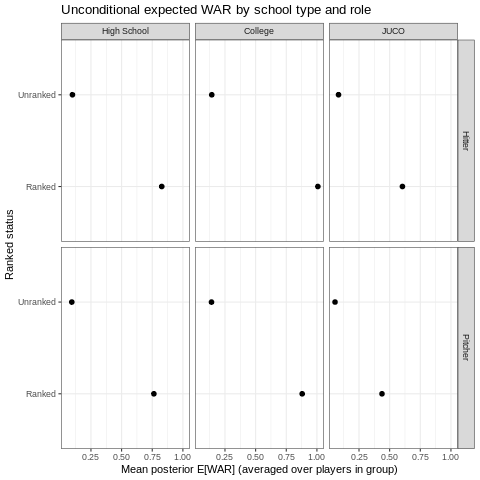

In [ ]:
%%R
ggplot(group_tab, aes(x = mean_ewar, y = ranked_lab)) +
  geom_point(size = 2) +
  facet_grid(role ~ school_type_3cat) +
  labs(
    x = "Mean posterior E[WAR] (averaged over players in group)",
    y = "Ranked status",
    title = "Unconditional expected WAR by school type and role"
  ) +
  theme_bw()


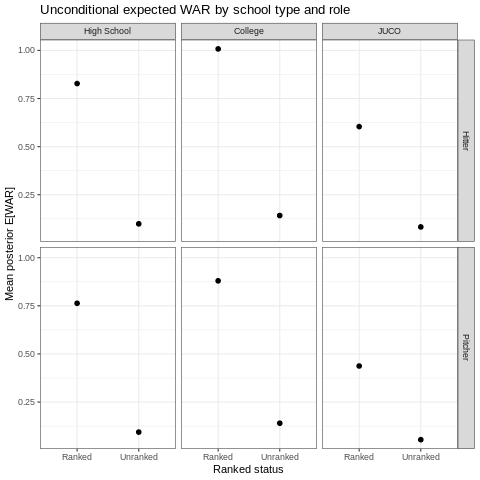

In [ ]:
%%R
ggplot(group_tab, aes(x = ranked_lab, y = mean_ewar)) +
  geom_point(size = 2) +
  facet_grid(role ~ school_type_3cat) +
  labs(
    x = "Ranked status",
    y = "Mean posterior E[WAR]",
    title = "Unconditional expected WAR by school type and role"
  ) +
  theme_bw()


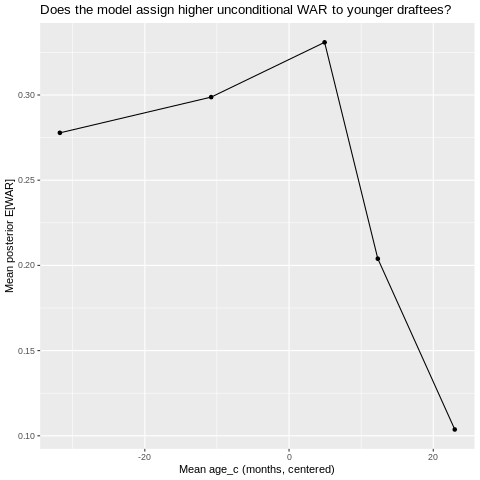

In [ ]:
%%R
df_age <- df_ewar %>%
  mutate(age_bin = ntile(age_c, 5))  # 1=youngest ... 5=oldest

age_tab <- df_age %>%
  group_by(age_bin) %>%
  summarize(
    n = n(),
    mean_age_c = mean(age_c),
    mean_ewar = mean(ewar_mean),
    .groups="drop"
  )

ggplot(age_tab, aes(x = mean_age_c, y = mean_ewar)) +
  geom_point() +
  geom_line() +
  labs(
    x = "Mean age_c (months, centered)",
    y = "Mean posterior E[WAR]",
    title = "Does the model assign higher unconditional WAR to younger draftees?"
  )


In [ ]:
%%R
df_age_sub <- df_age %>%
  filter(school_type_3cat == "College", is_pitcher == 1)

age_tab_sub <- df_age_sub %>%
  group_by(age_bin = ntile(age_c, 5)) %>%
  summarize(mean_age_c = mean(age_c), mean_ewar = mean(ewar_mean), n=n(), .groups="drop")

ggplot(age_tab_sub, aes(x = mean_age_c, y = mean_ewar)) +
  geom_point() +
  geom_line() +
  labs(
    x = "Mean age_c (months, centered)",
    y = "Mean posterior E[WAR]",
    title = "College hitters: younger vs older"
  )


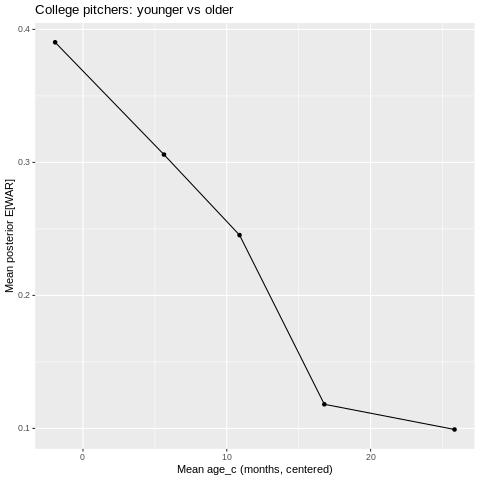

In [ ]:
%%R
df_age_sub <- df_age %>%
  filter(school_type_3cat == "College", is_pitcher == 1)

age_tab_sub <- df_age_sub %>%
  group_by(age_bin = ntile(age_c, 5)) %>%
  summarize(mean_age_c = mean(age_c), mean_ewar = mean(ewar_mean), n=n(), .groups="drop")

ggplot(age_tab_sub, aes(x = mean_age_c, y = mean_ewar)) +
  geom_point() +
  geom_line() +
  labs(
    x = "Mean age_c (months, centered)",
    y = "Mean posterior E[WAR]",
    title = "College pitchers: younger vs older"
  )


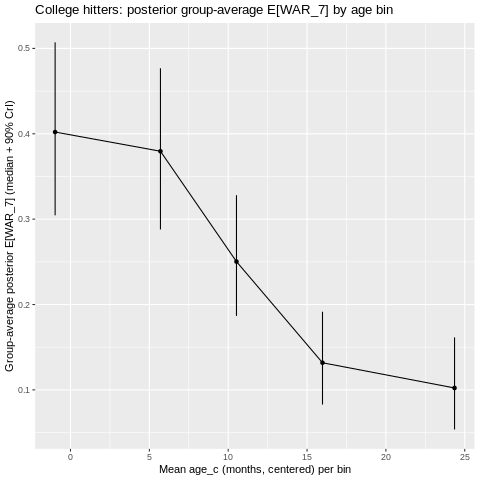

In [ ]:
%%R
library(dplyr)
library(ggplot2)
library(matrixStats)

plot_group_ewar_by_agebin_idx <- function(df_full, ewar_mat, idx, title,
                                          n_bins = 5, min_bin_n = 20) {
  df_sub  <- df_full[idx, , drop = FALSE]
  ewar_sub <- ewar_mat[, idx, drop = FALSE]  # S_keep x n_sub

  df2 <- df_sub %>%
    mutate(age_bin = ntile(age_c, n_bins)) %>%
    group_by(age_bin) %>%
    mutate(bin_n = n()) %>%
    ungroup() %>%
    filter(bin_n >= min_bin_n)

  # map df2 rows back to df_sub row positions (1..n_sub)
  idx_subpos <- as.integer(rownames(df2))
  bins <- sort(unique(df2$age_bin))

  draw_means <- sapply(bins, function(b) {
    cols_b <- idx_subpos[df2$age_bin == b]
    rowMeans(ewar_sub[, cols_b, drop = FALSE])
  }) # S_keep x B

  summ <- data.frame(
    age_bin    = bins,
    mean_age_c = sapply(bins, function(b) mean(df2$age_c[df2$age_bin == b])),
    n_players  = sapply(bins, function(b) sum(df2$age_bin == b)),
    ewar_med   = colMedians(draw_means),
    ewar_lo90  = colQuantiles(draw_means, probs = 0.05),
    ewar_hi90  = colQuantiles(draw_means, probs = 0.95)
  ) %>% arrange(mean_age_c)

  p <- ggplot(summ, aes(x = mean_age_c, y = ewar_med)) +
    geom_line() +
    geom_point() +
    geom_errorbar(aes(ymin = ewar_lo90, ymax = ewar_hi90), width = 0) +
    labs(
      x = "Mean age_c (months, centered) per bin",
      y = "Group-average posterior E[WAR_7] (median + 90% CrI)",
      title = title
    )

  list(summary = summ, draw_means = draw_means, plot = p)
}

# Example: College hitters
idx_col_hit <- which(df_used_war$school_type_3cat == "College" & df_used_war$is_pitcher == 0)
res_col_hit <- plot_group_ewar_by_agebin_idx(df_used_war, ewar_mat, idx_col_hit,
  "College hitters: posterior group-average E[WAR_7] by age bin")
res_col_hit$plot


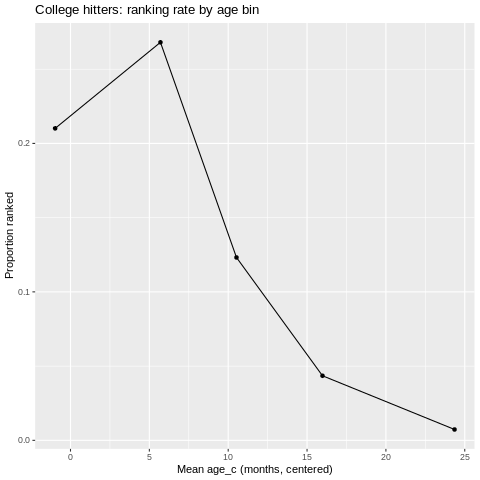

In [ ]:
%%R
library(dplyr)
library(ggplot2)

df_tmp <- df_used_war %>%
  filter(school_type_3cat=="College", is_pitcher==0) %>%
  mutate(age_bin = ntile(age_c, 5)) %>%
  group_by(age_bin) %>%
  summarize(mean_age_c = mean(age_c),
            prop_ranked = mean(ranked==1),
            n=n(), .groups="drop")

ggplot(df_tmp, aes(x = mean_age_c, y = prop_ranked)) +
  geom_point() + geom_line() +
  labs(x="Mean age_c (months, centered)", y="Proportion ranked",
       title="College hitters: ranking rate by age bin")


In [ ]:
%%R
library(dplyr)
library(ggplot2)
library(matrixStats)

plot_bin_posterior <- function(df_sub, ewar_mat, title, n_bins=5, min_n=20){

  # df_sub must be in the SAME ROW ORDER as ewar_mat columns
  idx <- as.integer(rownames(df_sub))
  stopifnot(all(!is.na(idx)))

  df_sub <- df_sub %>% mutate(age_bin = ntile(age_c, n_bins))

  bins <- sort(unique(df_sub$age_bin))

  summ <- lapply(bins, function(b){
    idx_b <- idx[df_sub$age_bin == b]
    if(length(idx_b) < min_n) return(NULL)

    dm <- rowMeans(ewar_mat[, idx_b, drop=FALSE])  # per-draw bin average

    data.frame(
      age_bin = b,
      mean_age_c = mean(df_sub$age_c[df_sub$age_bin==b]),
      n = length(idx_b),
      med = median(dm),
      lo90 = quantile(dm, 0.05),
      hi90 = quantile(dm, 0.95)
    )
  }) %>% bind_rows() %>% arrange(mean_age_c)

  ggplot(summ, aes(x=mean_age_c, y=med)) +
    geom_line() +
    geom_point() +
    geom_errorbar(aes(ymin=lo90, ymax=hi90), width=0) +
    geom_text(aes(label=paste0("n=", n)), vjust=-0.6, size=3) +
    labs(x="Mean age_c (months, centered)", y="Group-average posterior E[WAR]",
         title=title)
}

df_col_hit_ranked <- df_used_war %>%
  filter(school_type_3cat=="College", is_pitcher==0, ranked==1) %>%
  mutate(rowname = row_number())

df_col_hit_unranked <- df_used_war %>%
  filter(school_type_3cat=="College", is_pitcher==0, ranked==0) %>%
  mutate(rowname = row_number())

# IMPORTANT: these rownames must match the original row positions
rownames(df_col_hit_ranked) <- which(df_used_war$school_type_3cat=="College" & df_used_war$is_pitcher==0 & df_used_war$ranked==1)
rownames(df_col_hit_unranked) <- which(df_used_war$school_type_3cat=="College" & df_used_war$is_pitcher==0 & df_used_war$ranked==0)

plot_bin_posterior(df_col_hit_ranked, ewar_mat, "Ranked college hitters: bin-average E[WAR] with 90% CrI")
plot_bin_posterior(df_col_hit_unranked, ewar_mat, "Unranked college hitters: bin-average E[WAR] with 90% CrI")


Error in `arrange()`:
ℹ In argument: `..1 = mean_age_c`.
Caused by error:
! object 'mean_age_c' not found
Run `rlang::last_trace()` to see where the error occurred.
Warning messages:
1: Setting row names on a tibble is deprecated. 
2: Setting row names on a tibble is deprecated.
Error in arrange(., mean_age_c) : 
Caused by error:
! object 'mean_age_c' not found


RInterpreterError: Failed to parse and evaluate line 'library(dplyr)\nlibrary(ggplot2)\nlibrary(matrixStats)\n\nplot_bin_posterior <- function(df_sub, ewar_mat, title, n_bins=5, min_n=20){\n\n  # df_sub must be in the SAME ROW ORDER as ewar_mat columns\n  idx <- as.integer(rownames(df_sub))\n  stopifnot(all(!is.na(idx)))\n\n  df_sub <- df_sub %>% mutate(age_bin = ntile(age_c, n_bins))\n\n  bins <- sort(unique(df_sub$age_bin))\n\n  summ <- lapply(bins, function(b){\n    idx_b <- idx[df_sub$age_bin == b]\n    if(length(idx_b) < min_n) return(NULL)\n\n    dm <- rowMeans(ewar_mat[, idx_b, drop=FALSE])  # per-draw bin average\n\n    data.frame(\n      age_bin = b,\n      mean_age_c = mean(df_sub$age_c[df_sub$age_bin==b]),\n      n = length(idx_b),\n      med = median(dm),\n      lo90 = quantile(dm, 0.05),\n      hi90 = quantile(dm, 0.95)\n    )\n  }) %>% bind_rows() %>% arrange(mean_age_c)\n\n  ggplot(summ, aes(x=mean_age_c, y=med)) +\n    geom_line() +\n    geom_point() +\n    geom_errorba

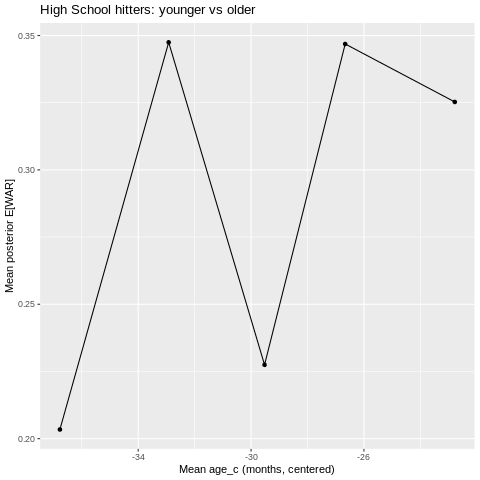

In [ ]:
%%R
df_age_sub <- df_age %>%
  filter(school_type_3cat == "High School", is_pitcher == 0)

age_tab_sub <- df_age_sub %>%
  group_by(age_bin = ntile(age_c, 5)) %>%
  summarize(mean_age_c = mean(age_c), mean_ewar = mean(ewar_mean), n=n(), .groups="drop")

ggplot(age_tab_sub, aes(x = mean_age_c, y = mean_ewar)) +
  geom_point() +
  geom_line() +
  labs(
    x = "Mean age_c (months, centered)",
    y = "Mean posterior E[WAR]",
    title = "High School hitters: younger vs older"
  )


In [ ]:
%%R
age_tab_sub <- df_age %>%
  filter(school_type_3cat == "High School", is_pitcher == 0) %>%
  mutate(age_bin = ntile(age_c, 5)) %>%
  group_by(age_bin) %>%
  summarize(
    n = n(),
    mean_age_c = mean(age_c),
    min_age_c = min(age_c),
    max_age_c = max(age_c),
    mean_ewar = mean(ewar_mean),
    sd_ewar = sd(ewar_mean),
    .groups="drop"
  )

age_tab_sub


# A tibble: 5 × 7
  age_bin     n mean_age_c min_age_c max_age_c mean_ewar sd_ewar
    <int> <int>      <dbl>     <dbl>     <dbl>     <dbl>   <dbl>
1       1    62      -36.8     -40.9     -34.7     0.203   0.262
2       2    62      -32.9     -34.6     -31.0     0.347   0.482
3       3    62      -29.5     -30.9     -28.2     0.227   0.365
4       4    62      -26.7     -28.1     -25.2     0.347   0.444
5       5    61      -22.8     -25.2     -15.6     0.325   0.444


In [ ]:
%%R
df_age_sub %>%
  summarize(
    n = n(),
    age_min = min(age_c),
    age_p10 = quantile(age_c, 0.10),
    age_med = median(age_c),
    age_p90 = quantile(age_c, 0.90),
    age_max = max(age_c),
    n_unique_age = n_distinct(age_c)
  )


# A tibble: 1 × 7
      n age_min age_p10 age_med age_p90 age_max n_unique_age
  <int>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>        <int>
1   309   -40.9   -36.2   -29.5   -23.5   -15.6          241


In [ ]:
%%R
topN <- 50
top_ewar <- df_ewar %>% arrange(desc(ewar_mean)) %>% slice(1:topN)

top_ewar %>%
  summarize(
    pct_college = mean(school_type_3cat == "College"),
    pct_hitters = mean(is_pitcher == 0),
    pct_ranked  = mean(ranked == 1),
    mean_age_c  = mean(age_c)
  )


# A tibble: 1 × 4
  pct_college pct_hitters pct_ranked mean_age_c
        <dbl>       <dbl>      <dbl>      <dbl>
1        0.68        0.58          1      -7.09


In [ ]:
%%R
df_ewar %>%
  summarize(
    pct_college = mean(school_type_3cat == "College"),
    pct_hitters = mean(is_pitcher == 0),
    pct_ranked  = mean(ranked == 1),
    mean_age_c  = mean(age_c)
  )


# A tibble: 1 × 4
  pct_college pct_hitters pct_ranked mean_age_c
        <dbl>       <dbl>      <dbl>      <dbl>
1       0.672       0.455      0.160     -0.490


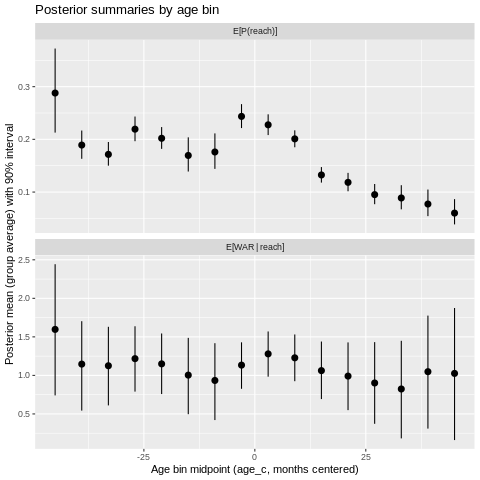

In [ ]:
%%R
# Each dot is the posterior distribution of the average reach probability
# or avg conditional WAR
library(dplyr)
library(ggplot2)
library(matrixStats)

stopifnot(nrow(p_reach) == S_keep, ncol(p_reach) == N)
stopifnot(nrow(mu_war)  == S_keep, ncol(mu_war)  == N)
stopifnot(nrow(df_used_war) == N)

# ----- 1) Define age bins (6-month bins on centered-month scale) -----
age_c <- df_used_war$age_c

bin_width <- 6
brks <- seq(floor(min(age_c)/bin_width)*bin_width,
            ceiling(max(age_c)/bin_width)*bin_width,
            by = bin_width)

df_age <- df_used_war %>%
  mutate(
    age_bin = cut(age_c, breaks = brks, include.lowest = TRUE, right = FALSE)
  )

# Bin midpoints (for x-axis)
bin_levels <- levels(df_age$age_bin)
bin_mid <- sapply(bin_levels, function(lbl){
  # lbl looks like "[a,b)" or "[a,b]"
  nums <- gsub("\\[|\\)|\\]|\\(|\\s", "", lbl)
  parts <- strsplit(nums, ",")[[1]]
  mean(as.numeric(parts))
})
bin_map <- data.frame(age_bin = bin_levels, age_mid = bin_mid)

df_age <- df_age %>% left_join(bin_map, by = "age_bin")

# ----- 2) For each draw, compute the mean within each age bin -----
idx_list <- split(seq_len(N), df_age$age_bin)

draw_mean_by_bin <- function(mat, idx_list) {
  out <- matrix(NA_real_, nrow = nrow(mat), ncol = length(idx_list))
  colnames(out) <- names(idx_list)
  for (j in seq_along(idx_list)) {
    idx <- idx_list[[j]]
    out[, j] <- rowMeans2(mat[, idx, drop = FALSE])
  }
  out
}

p_bin_draw  <- draw_mean_by_bin(p_reach, idx_list)  # S_keep x B
mu_bin_draw <- draw_mean_by_bin(mu_war,  idx_list)  # S_keep x B

summ_bin <- function(draw_mat) {
  data.frame(
    age_bin = colnames(draw_mat),
    mean = colMeans(draw_mat),
    lo90 = colQuantiles(draw_mat, probs = 0.05),
    hi90 = colQuantiles(draw_mat, probs = 0.95)
  ) %>% left_join(bin_map, by = "age_bin") %>% arrange(age_mid)
}

p_bin_summ  <- summ_bin(p_bin_draw)  %>% mutate(quantity = "E[P(reach)]")
mu_bin_summ <- summ_bin(mu_bin_draw) %>% mutate(quantity = "E[WAR | reach]")

df_plot <- bind_rows(p_bin_summ, mu_bin_summ)

# ----- 3) Plot: point + 90% interval vs age-bin midpoint -----
ggplot(df_plot, aes(x = age_mid, y = mean)) +
  geom_pointrange(aes(ymin = lo90, ymax = hi90)) +
  facet_wrap(~ quantity, scales = "free_y", ncol = 1) +
  labs(
    x = "Age bin midpoint (age_c, months centered)",
    y = "Posterior mean (group average) with 90% interval",
    title = "Posterior summaries by age bin"
  )


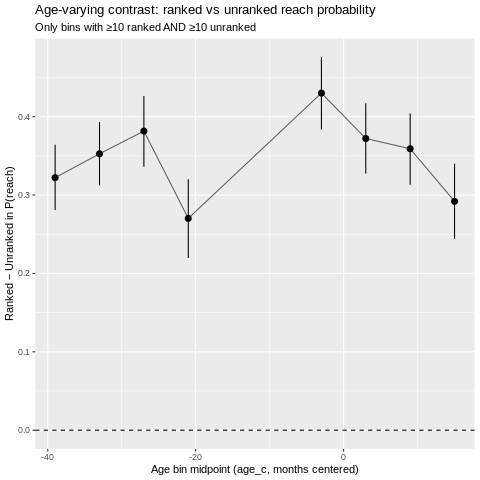

In [ ]:
%%R
library(matrixStats)
library(dplyr)
library(ggplot2)

# 1) counts per age bin and ranked status
count_tab <- df_age %>%
  group_by(age_bin) %>%
  summarize(
    n_ranked   = sum(ranked == 1, na.rm=TRUE),
    n_unranked = sum(ranked == 0, na.rm=TRUE),
    .groups="drop"
  ) %>%
  left_join(bin_map, by="age_bin") %>%
  arrange(age_mid)

# 2) compute per-draw ranked - unranked contrast only where both groups are big enough
min_n <- 10  # <-- raise this to stabilize the plot (10, 15, 20)

ok_bins <- count_tab %>%
  filter(n_ranked >= min_n, n_unranked >= min_n) %>%
  pull(age_bin) %>%
  as.character()

diff_draw <- matrix(NA_real_, nrow = S_keep, ncol = length(ok_bins))
colnames(diff_draw) <- ok_bins

for (j in seq_along(ok_bins)) {
  b <- ok_bins[j]
  idx_b <- idx_list[[b]]
  idx_r  <- idx_b[df_age$ranked[idx_b] == 1]
  idx_ur <- idx_b[df_age$ranked[idx_b] == 0]

  pr  <- rowMeans2(p_reach[, idx_r,  drop=FALSE])
  pur <- rowMeans2(p_reach[, idx_ur, drop=FALSE])
  diff_draw[, j] <- pr - pur
}

diff_summ <- data.frame(
  age_bin   = colnames(diff_draw),
  diff_mean = colMeans(diff_draw),
  diff_lo90 = colQuantiles(diff_draw, probs = 0.05),
  diff_hi90 = colQuantiles(diff_draw, probs = 0.95)
) %>%
  left_join(count_tab, by="age_bin") %>%
  arrange(age_mid)

ggplot(diff_summ, aes(x = age_mid, y = diff_mean)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_pointrange(aes(ymin = diff_lo90, ymax = diff_hi90)) +
  geom_line(alpha = 0.6) +
  labs(
    x = "Age bin midpoint (age_c, months centered)",
    y = "Ranked − Unranked in P(reach)",
    title = "Age-varying contrast: ranked vs unranked reach probability",
    subtitle = paste0("Only bins with ≥", min_n, " ranked AND ≥", min_n, " unranked")
  )
